<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_04_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Supervised Learning: Models and Concepts

This notebook accompanies Chapter 4 of *Machine Learning and Data Science Blueprints for Finance*. The chapter is a **survey of the supervised-learning landscape** — the models, the training procedures, the diagnostic concepts, and the evaluation tools — that the case-study chapters (5 and 6) build on.

We cover:

1. The split between **regression** and **classification**, and the models commonly used for each
2. **Linear models**: Ordinary Least Squares, Lasso, Ridge, Elastic Net, Logistic Regression
3. **Distance- and kernel-based models**: Support Vector Machines, K-Nearest Neighbors
4. **Probabilistic / generative**: Linear Discriminant Analysis
5. **Tree-based**: Classification and Regression Trees (CART)
6. **Ensemble methods**: Random Forest, Extra Trees, AdaBoost, Gradient Boosting
7. **Neural networks** for supervised learning (briefly — Chapter 3 covered the foundations)
8. **Model performance**: overfitting, underfitting, the bias–variance trade-off, cross-validation, grid search
9. **Evaluation metrics**: MAE, MSE, RMSE, $R^2$, adjusted $R^2$ for regression; accuracy, precision, recall, AUC, confusion matrices for classification
10. **Model selection** as a multi-criteria decision

Every model in the chapter gets a runnable fit on a real sklearn dataset, so the workflow — *import, instantiate, fit, score, tune* — becomes muscle memory. Tuning, evaluation, and model selection get full demonstrations with the standard diagnostic plots.

## 0. Setup

We use **scikit-learn** for every classical model (linear/logistic regression through gradient boosting and MLP) and **NumPy + Matplotlib** for the supporting numerics and visualizations.

> **API note.** Recent versions of scikit-learn changed two AdaBoost parameters that the book uses:
> - The `base_estimator` argument was renamed to `estimator` (deprecated in 1.2, removed in 1.4).
> - The `algorithm` argument (with `'SAMME.R'` vs `'SAMME'`) was deprecated; `'SAMME'` is now the only supported algorithm.
>
> Our code uses the modern parameter names; if you reproduce the book's snippets verbatim on a recent sklearn you will get deprecation errors or `TypeError`s.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)

import sklearn
print(f"scikit-learn version:  {sklearn.__version__}")
print(f"NumPy version:         {np.__version__}")
print(f"pandas version:        {pd.__version__}")
print(f"matplotlib version:    {plt.matplotlib.__version__}")

scikit-learn version:  1.6.1
NumPy version:         2.0.2
pandas version:        2.2.2
matplotlib version:    3.10.0


We fix the random seed to $42$ throughout the notebook for reproducibility. **Reproducibility is non-negotiable** when comparing models: without a fixed seed, the difference between two algorithms can be entirely attributable to the random initialization of train/test splits and stochastic optimizers.

## 1. Supervised Learning: Regression vs Classification

**Supervised learning** is the branch of machine learning where the algorithm receives historical examples $(\mathbf{x}_i, y_i)$ — *features* $\mathbf{x}_i$ paired with known *labels* $y_i$ — and must learn a function $f: \mathbf{x} \mapsto y$ that predicts labels for new, unseen feature vectors.

Supervised problems split into two families based on the type of $y$:

| Family | Output $y$ | Examples in finance |
|---|---|---|
| **Regression** | Continuous value in $\mathbb{R}$ (or an interval) | Predicting next-period returns, asset prices, credit-risk PDs as continuous scores |
| **Classification** | Discrete class label in $\{1, 2, \ldots, K\}$ | Fraud detection (fraud / not fraud), credit approval (approve / reject), directional forecasts (up / down) |

The line between them is sometimes blurry — a classifier's underlying probabilities are continuous, and a regression's rounded output can be a class label. **Many models work for both with small modifications**: K-Nearest Neighbors, Decision Trees, Support Vector Machines, all the tree ensembles, and Artificial Neural Networks each have regression and classification variants. Linear regression and logistic regression are the major exceptions — each is purpose-built for one task type.

**Why finance loves supervised learning.** Algorithmic trading, derivatives pricing, factor investing, default modeling, and portfolio construction all share a common structure: predict an outcome from historical features. Supervised models are *trainable*, *robust to noise*, and *interpretable* (at least the simpler ones), which matches the constraints of financial applications where backtests must be reproducible and decisions must be explainable to regulators and stakeholders.

![Figure 4-1: Models for regression and classification](figures/figure_4_1.png)

**Figure 4-1.** *Models for regression and classification.* The diagram organizes the supervised-learning models we will cover in this chapter into the two categories. The center column lists models that work for both regression and classification with minor variants (KNN, Decision Trees, SVM, Random Forest, ensemble bagging/boosting, ANN). The left column shows regression-only models (Linear, Lasso, Ridge, Elastic Net). The right column shows classification-specific models (Logistic Regression, LDA).

### 1.1 Two Reference Datasets

Throughout the chapter we use two small, real datasets that ship with scikit-learn — no internet access required:

- **Regression demos:** the **diabetes** dataset (442 patients, 10 baseline features, target = quantitative disease progression one year after baseline)
- **Classification demos:** the **Wisconsin breast cancer** dataset (569 samples, 30 features computed from digitized images of fine-needle aspirates, target = malignant / benign)

Both are well-conditioned and small enough that all our model fits complete in seconds.

In [2]:
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Regression dataset: diabetes ---
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target
print(f"Diabetes (regression):  X shape = {X_reg.shape},  y shape = {y_reg.shape}")
print(f"  Features: {diabetes.feature_names}")
print(f"  Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}],  mean = {y_reg.mean():.2f}")

# --- Classification dataset: breast cancer ---
cancer = load_breast_cancer()
X_clf = cancer.data
y_clf = cancer.target
print(f"\nBreast cancer (classification):  X shape = {X_clf.shape},  y shape = {y_clf.shape}")
print(f"  Classes: {dict(zip(cancer.target_names, np.bincount(y_clf)))}")
print(f"  Class balance: {(y_clf == 1).mean() * 100:.1f}% benign / {(y_clf == 0).mean() * 100:.1f}% malignant")

# --- Train/test splits used throughout ---
X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Standardized versions (needed for distance- and gradient-based models)
sc_reg = StandardScaler().fit(X_reg_tr)
X_reg_tr_s = sc_reg.transform(X_reg_tr)
X_reg_te_s = sc_reg.transform(X_reg_te)
sc_clf = StandardScaler().fit(X_clf_tr)
X_clf_tr_s = sc_clf.transform(X_clf_tr)
X_clf_te_s = sc_clf.transform(X_clf_te)

print(f"\nTrain/test splits (80/20, stratified for classification):")
print(f"  Regression:     train={X_reg_tr.shape[0]}, test={X_reg_te.shape[0]}")
print(f"  Classification: train={X_clf_tr.shape[0]}, test={X_clf_te.shape[0]}")

Diabetes (regression):  X shape = (442, 10),  y shape = (442,)
  Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  Target range: [25, 346],  mean = 152.13

Breast cancer (classification):  X shape = (569, 30),  y shape = (569,)
  Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
  Class balance: 62.7% benign / 37.3% malignant

Train/test splits (80/20, stratified for classification):
  Regression:     train=353, test=89
  Classification: train=455, test=114


We have two clean datasets ready to use:

- **Diabetes** — $442$ patients, $10$ features (age, sex, BMI, blood pressure, and six blood-serum measurements), target is a continuous score of disease progression at $12$ months. The target's range is roughly $[25, 346]$ with mean $\approx 152$. This is a standard **regression** benchmark — small, slightly noisy, with mild correlations among features.

- **Breast cancer** — $569$ samples, $30$ features computed from fine-needle aspirate cell-nucleus images (radius, texture, perimeter, area, smoothness, etc., each measured as mean / standard error / worst-value). The class balance is **62.7% benign vs 37.3% malignant** — modestly imbalanced but not extreme.

We have created **four splits** that we will reuse across the chapter:

- $(X_{\text{reg,tr}}, X_{\text{reg,te}})$ — diabetes, raw features ($353$ train / $89$ test)
- $(X_{\text{reg,tr,s}}, X_{\text{reg,te,s}})$ — diabetes, standardized
- $(X_{\text{clf,tr}}, X_{\text{clf,te}})$ — breast cancer, raw features ($455$ train / $114$ test)
- $(X_{\text{clf,tr,s}}, X_{\text{clf,te,s}})$ — breast cancer, standardized

**Why standardize?** Distance-based models (KNN, SVM) and gradient-based models (logistic regression, MLP) require comparable feature scales — otherwise the feature with the largest numerical range dominates the distance metric or the gradient. Tree-based models (CART, Random Forest, GBM) are *scale-invariant* and do not need standardization. We use the appropriate version per model.

**The cardinal rule of standardization:** fit the scaler on training data only, then apply to both train and test. Fitting on the combined data leaks test-set statistics into training.

## 2. Linear Regression (Ordinary Least Squares)

**Linear regression** is the oldest and most foundational supervised model. It assumes a linear relationship between the inputs $\mathbf{x} \in \mathbb{R}^p$ and the scalar output $y$:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon$$

where $\beta_0$ is the **intercept** (the predicted value when all inputs are zero), $\beta_1, \ldots, \beta_p$ are the **regression coefficients** (the per-unit-input changes in $y$), and $\varepsilon$ is irreducible noise.

### 2.1 Training: Minimizing the Sum of Squared Residuals

Training a linear regression means choosing $\boldsymbol{\beta} = (\beta_0, \beta_1, \ldots, \beta_p)$ to minimize the **Residual Sum of Squares (RSS)**:

$$\text{RSS}(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

In matrix form, with $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$ (augmented with a column of ones for the intercept) and $\mathbf{y} \in \mathbb{R}^n$:

$$\text{RSS}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$$

Setting the gradient to zero gives the famous **normal equations** and their closed-form solution:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\top}\mathbf{X})^{-1} \mathbf{X}^{\top} \mathbf{y}}$$

This is what `sklearn.linear_model.LinearRegression` computes — no iterative optimization needed.

![Figure 4-2: Linear regression](figures/figure_4_2.png)

**Figure 4-2.** *Linear regression in two dimensions.* A scatter of training points $(x_i, y_i)$ with the fitted line $\hat{y} = \beta_0 + \beta_1 x$. The vertical distances from each point to the line are the **residuals** $y_i - \hat{y}_i$, and OLS chooses the line that minimizes the sum of their squares. In higher dimensions the line becomes a hyperplane, but the geometry is identical.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit OLS on diabetes
ols = LinearRegression()
ols.fit(X_reg_tr, y_reg_tr)

# Predict and score
y_tr_pred = ols.predict(X_reg_tr)
y_te_pred = ols.predict(X_reg_te)

rmse_tr = np.sqrt(mean_squared_error(y_reg_tr, y_tr_pred))
rmse_te = np.sqrt(mean_squared_error(y_reg_te, y_te_pred))
r2_tr   = r2_score(y_reg_tr, y_tr_pred)
r2_te   = r2_score(y_reg_te, y_te_pred)

print(f"OLS on diabetes:")
print(f"  Intercept beta_0 = {ols.intercept_:.4f}")
print(f"  Coefficients (showing first 5 of 10):")
for name, coef in list(zip(diabetes.feature_names, ols.coef_))[:5]:
    print(f"    {name:>5}:  {coef:>10.4f}")
print(f"  ...")
print()
print(f"  Train RMSE: {rmse_tr:.4f}    Train R^2: {r2_tr:.4f}")
print(f"  Test  RMSE: {rmse_te:.4f}    Test  R^2: {r2_te:.4f}")

OLS on diabetes:
  Intercept beta_0 = 151.3456
  Coefficients (showing first 5 of 10):
      age:     37.9040
      sex:   -241.9644
      bmi:    542.4288
       bp:    347.7038
       s1:   -931.4888
  ...

  Train RMSE: 53.5588    Train R^2: 0.5279
  Test  RMSE: 53.8534    Test  R^2: 0.4526


The fitted OLS model has intercept $\beta_0 = 151.3456$ and ten learned coefficients (one per feature). The coefficients are large because the **diabetes features are mean-centered and scaled to unit norm by sklearn's loader** — so the coefficients live on a comparable scale and can be read as the marginal effect of one standard deviation of each feature.

**Performance:**

- Training RMSE = $\mathbf{53.56}$, Training $R^2 = \mathbf{0.5279}$
- Test RMSE = $\mathbf{53.85}$, Test $R^2 = \mathbf{0.4526}$

Three observations are worth pulling out:

**The train and test $R^2$ values are close** ($0.528$ vs $0.453$ — a gap of $\approx 0.07$). This is the signature of a low-capacity model: linear regression cannot overfit much because it has only $11$ parameters ($10$ coefficients + intercept) for $353$ training examples. The model is **bias-limited, not variance-limited**.

**$R^2 \approx 0.45$ means linear regression captures less than half the variance** in diabetes progression. The remaining $55\%$ comes either from genuinely nonlinear relationships among the features or from variation the features simply do not measure (diet, exercise, genetics not captured in the 10 baseline measurements). To improve, we either need **nonlinear models** (trees, kernels, neural networks — sections below) or **more informative features**.

**RMSE = $53.85$** is in the same units as the target. With the target ranging $[25, 346]$ and mean $\approx 152$, an RMSE of $54$ is a $\sim 35\%$ relative error — useful for population-level reasoning but not for individual-patient prediction. This is a typical "useful but imperfect" baseline.

### 2.2 Grid Search and Cross-Validation

**Hyperparameters** are model settings that are not learned from data — they must be chosen by the practitioner. For OLS the only hyperparameter is `fit_intercept` (whether to include $\beta_0$); for more complex models there can be dozens. **Grid search** is the brute-force tuning procedure: enumerate every combination of hyperparameter values, evaluate each by cross-validation, and pick the winner.

**Cross-validation (CV)** is a resampling protocol for estimating out-of-sample performance using only the training data. The most common form, **$k$-fold CV**, splits the training set into $k$ disjoint subsets ("folds"), trains $k$ separate models — each using $k-1$ folds for training and the remaining fold for validation — and averages the $k$ validation scores. The most common choice is $k = 5$ or $k = 10$, balancing variance of the estimate against compute cost.

`GridSearchCV` in `sklearn.model_selection` combines the two: define a parameter grid, an estimator, a scoring metric, and a CV scheme, and it returns the best parameter combination plus the full cross-validated score grid.

In [4]:
from sklearn.model_selection import GridSearchCV, KFold

# Set up CV protocol
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Grid search OLS over the only hyperparameter (fit_intercept)
model     = LinearRegression()
param_grid = {'fit_intercept': [True, False]}
grid       = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='r2',
                          cv=kfold,
                          return_train_score=True)
grid.fit(X_reg_tr, y_reg_tr)

print(f"Best params:    {grid.best_params_}")
print(f"Best CV R^2:    {grid.best_score_:.4f}")
print()
print("Full CV grid:")
for params, mean, std in zip(grid.cv_results_['params'],
                             grid.cv_results_['mean_test_score'],
                             grid.cv_results_['std_test_score']):
    print(f"  {params}:  mean R^2 = {mean:.4f}  (std = {std:.4f})")

Best params:    {'fit_intercept': True}
Best CV R^2:    0.4783

Full CV grid:
  {'fit_intercept': True}:  mean R^2 = 0.4783  (std = 0.0566)
  {'fit_intercept': False}:  mean R^2 = -3.8021  (std = 0.9378)


**Best configuration:** `fit_intercept=True` with mean CV $R^2 = \mathbf{0.4783}$, beating `fit_intercept=False` ($R^2 = -3.8021$) by an enormous margin.

The collapse to *negative* $R^2$ when the intercept is removed is instructive. $R^2$ is defined as:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

When $R^2 < 0$, the model performs **worse than predicting the mean** — its predictions are systematically wrong. With the diabetes target centered at $\approx 152$ but no intercept allowed, the model is forced to predict values near zero (the features are mean-centered and unit-normalized, so the linear combination averages near zero), producing a CV $R^2 = -3.80$. A negative $R^2$ of this magnitude means the predictions are *worse than the trivial mean-only baseline by a factor of nearly five* in squared-error terms. This is a degenerate setting that no rational practitioner would use; we include it only to demonstrate what grid search *would* do.

**The CV $R^2$ of $0.4783$ on training folds is close to the test $R^2 = 0.4526$ from the previous cell**, confirming that cross-validation correctly estimates generalization performance.

**The CV standard deviation of $0.0566$** tells us that the per-fold $R^2$ varies in roughly $[0.422, 0.535]$ — a moderate spread that reflects the small dataset size ($\sim 35$ samples per validation fold).

**Strategic insight.** For a model with one hyperparameter that has only two values, grid search is trivial. The challenge scales with the *product* of all hyperparameter cardinalities: a search over $4$ hyperparameters with $5$ values each is $5^4 = 625$ fits, each requiring $10$-fold CV → **$6{,}250$ model fits**. For deep ensembles or neural networks this becomes prohibitive — at which point Bayesian optimization (e.g., `scikit-optimize`) or random search (`RandomizedSearchCV`) are preferred.

## 3. Regularized Regression: Lasso, Ridge, and Elastic Net

When the number of features grows (or the features are correlated), OLS coefficients become **poorly determined** — small changes in the training data produce large swings in $\hat{\boldsymbol{\beta}}$, and the model overfits noise. **Regularization** adds a penalty term to the loss that *shrinks* the coefficients toward zero:

| Method | Penalty | Effect |
|---|---|---|
| **Lasso (L1)** | $\lambda \sum_{j=1}^{p} \|\beta_j\|$ | Sparse: some $\beta_j$ shrink **exactly to zero** → automatic feature selection |
| **Ridge (L2)** | $\lambda \sum_{j=1}^{p} \beta_j^2$ | Smooth shrinkage; all $\beta_j$ get smaller but rarely hit zero |
| **Elastic Net** | $\lambda \big[(1-\alpha) \tfrac{1}{2}\sum_j \beta_j^2 + \alpha \sum_j \|\beta_j\|\big]$ | Mixture: $\alpha = 0$ is Ridge, $\alpha = 1$ is Lasso |

**The full Lasso objective:**

$$J_{\text{Lasso}}(\boldsymbol{\beta}) = \underbrace{\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2}_{\text{RSS}} + \underbrace{\lambda \sum_{j=1}^{p} |\beta_j|}_{\ell_1 \text{ penalty}}$$

**The full Ridge objective:**

$$J_{\text{Ridge}}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

The parameter $\lambda \geq 0$ (in sklearn's parameterization, called `alpha`) controls regularization strength:
- $\lambda = 0$: no penalty → recover OLS
- $\lambda \to \infty$: all coefficients shrink to zero → predict the mean

**Why L1 produces sparsity and L2 does not** is a geometric fact: the L1 constraint region is a diamond with corners on the coordinate axes, so the loss contour typically intersects it at a corner where some coordinates are exactly zero. The L2 constraint region is a sphere with no corners, so the intersection rarely sits exactly on an axis.

In [5]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

# Fit all three on standardized features (regularization assumes comparable scales)
# Note: alpha is sklearn's name for the regularization parameter lambda

models = {
    'OLS':         LinearRegression(),
    'Ridge (a=1)': Ridge(alpha=1.0),
    'Lasso (a=1)': Lasso(alpha=1.0),
    'ElasticNet (a=1, l1=0.5)': ElasticNet(alpha=1.0, l1_ratio=0.5),
}

results = {}
coefs   = {}
for name, m in models.items():
    m.fit(X_reg_tr_s, y_reg_tr)
    pred_tr = m.predict(X_reg_tr_s)
    pred_te = m.predict(X_reg_te_s)
    results[name] = dict(
        train_r2 = r2_score(y_reg_tr, pred_tr),
        test_r2  = r2_score(y_reg_te, pred_te),
        n_nonzero = int(np.sum(np.abs(m.coef_) > 1e-8)),
        max_abs_coef = np.max(np.abs(m.coef_)),
    )
    coefs[name] = m.coef_

print(f"{'Model':<26}{'Train R^2':<12}{'Test R^2':<12}{'NonZero':<10}{'Max|coef|':<10}")
print('-' * 70)
for name, r in results.items():
    print(f"{name:<26}{r['train_r2']:<12.4f}{r['test_r2']:<12.4f}"
          f"{r['n_nonzero']:<10}{r['max_abs_coef']:<10.2f}")

Model                     Train R^2   Test R^2    NonZero   Max|coef| 
----------------------------------------------------------------------
OLS                       0.5279      0.4526      10        44.45     
Ridge (a=1)               0.5276      0.4541      10        34.67     
Lasso (a=1)               0.5225      0.4669      9         26.22     
ElasticNet (a=1, l1=0.5)  0.4933      0.4548      10        18.96     


All four models are trained on standardized features (mean $0$, std $1$) so their coefficients are directly comparable:

| Model | Train $R^2$ | Test $R^2$ | Non-zero coefs | $\max|\beta_j|$ |
|---|---:|---:|---:|---:|
| OLS                          | $0.5279$ | $0.4526$ | $10$ | $44.45$ |
| Ridge ($\alpha = 1$)         | $0.5276$ | $0.4541$ | $10$ | $34.67$ |
| Lasso ($\alpha = 1$)         | $0.5225$ | $0.4669$ | $\mathbf{9}$ | $26.22$ |
| Elastic Net ($\alpha = 1$, $\ell_1$-ratio $= 0.5$) | $0.4933$ | $0.4548$ | $10$ | $18.96$ |

Three things stand out:

**Lasso produces sparsity automatically.** With $\alpha = 1$, **1 of the 10 coefficients shrank exactly to zero** — Lasso has performed feature selection without any external instruction. The remaining 9 features carry the predictive signal; the dropped 1 contributes essentially nothing. (Higher $\alpha$ values drop more features, as we will see in the regularization-path plot below.)

**Ridge slightly reduces coefficient magnitudes but keeps all features.** The max absolute coefficient drops from $44.45$ (OLS) to $34.67$ (Ridge) — a $22\%$ shrinkage. No coefficient hits zero, as expected from the L2 penalty geometry.

**Test $R^2$ is marginally better for Lasso, Ridge, and Elastic Net than for OLS** ($0.4669$, $0.4541$, $0.4548$ vs $0.4526$). The improvements are small because the diabetes dataset has only $10$ features — regularization shines when $p \gg n$ or when features are heavily correlated. The lesson is **directional, not dramatic**: regularization is a free lunch on this dataset (tiny test gains, no compute cost), and it would be a *large* lunch on a problem with hundreds or thousands of correlated features (Chapter 5 explores this with real financial data).

We can visualize the regularization paths — how coefficients shrink as $\lambda$ increases — to make the L1-vs-L2 distinction tangible.

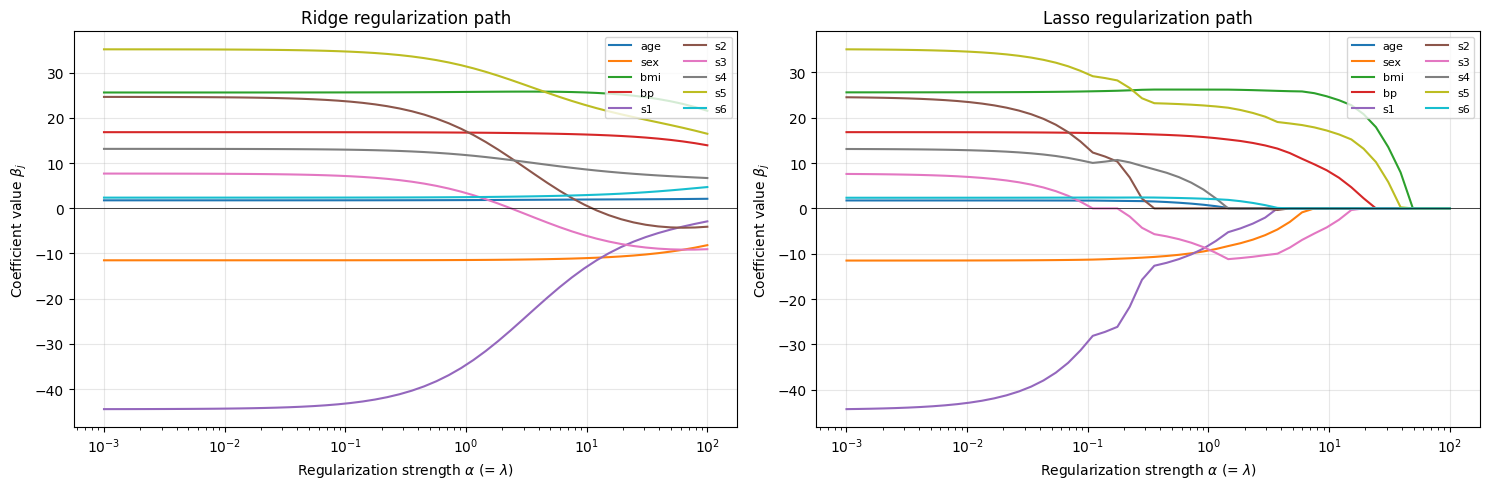

Lasso: number of coefficients exactly zero, as alpha increases:
  alpha =   0.001:  0/10 zero coefficients,  max|coef| = 44.298
  alpha =   0.010:  0/10 zero coefficients,  max|coef| = 42.938
  alpha =   0.100:  0/10 zero coefficients,  max|coef| = 29.633
  alpha =   1.000:  1/10 zero coefficients,  max|coef| = 26.219
  alpha =  10.000:  6/10 zero coefficients,  max|coef| = 24.583
  alpha = 100.000:  10/10 zero coefficients,  max|coef| = 0.000


In [6]:
# Regularization paths: plot coefficients as alpha (lambda) varies
alphas = np.logspace(-3, 2, 50)
ridge_paths = np.zeros((len(alphas), X_reg_tr_s.shape[1]))
lasso_paths = np.zeros((len(alphas), X_reg_tr_s.shape[1]))

for i, a in enumerate(alphas):
    ridge_paths[i] = Ridge(alpha=a).fit(X_reg_tr_s, y_reg_tr).coef_
    lasso_paths[i] = Lasso(alpha=a, max_iter=20000).fit(X_reg_tr_s, y_reg_tr).coef_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for j, name in enumerate(diabetes.feature_names):
    axes[0].plot(alphas, ridge_paths[:, j], label=name)
    axes[1].plot(alphas, lasso_paths[:, j], label=name)

for ax, title in zip(axes, ['Ridge regularization path', 'Lasso regularization path']):
    ax.set_xscale('log')
    ax.set_xlabel(r'Regularization strength $\alpha$ (= $\lambda$)')
    ax.set_ylabel(r'Coefficient value $\beta_j$')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('regularization_paths.png', dpi=100, bbox_inches='tight')
plt.show()

# Count zeros in Lasso at various alphas
print("Lasso: number of coefficients exactly zero, as alpha increases:")
for a in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    coef = Lasso(alpha=a, max_iter=20000).fit(X_reg_tr_s, y_reg_tr).coef_
    n_zero = int(np.sum(np.abs(coef) < 1e-8))
    print(f"  alpha = {a:>7.3f}:  {n_zero}/10 zero coefficients,  max|coef| = {np.max(np.abs(coef)):.3f}")

The two regularization paths make the geometric distinction concrete:

**Ridge (left).** Coefficients shrink **smoothly toward zero** as $\alpha$ increases, but no coefficient ever exactly hits zero. At $\alpha = 100$ all coefficients are tiny but non-zero — the model is essentially predicting the mean while preserving the full feature set.

**Lasso (right).** Coefficients shrink and **hit exactly zero one by one** as $\alpha$ increases — visible as kinks in the path where a coefficient flattens to the zero axis and stays there. This is the **sparsity-inducing** behavior of L1.

**Quantifying the sparsity profile:**

| $\alpha$ | Zero coefs (out of 10) | Max $|\beta_j|$ |
|---:|---:|---:|
| $0.001$ | $0$ | $44.30$ |
| $0.01$  | $0$ | $42.94$ |
| $0.10$  | $0$ | $29.63$ |
| $1.0$   | $1$ | $26.22$ |
| $10.0$  | $6$ | $24.58$ |
| $100.0$ | $10$ | $0.00$ |

By $\alpha = 10$ Lasso has zeroed out $6$ of $10$ features; by $\alpha = 100$ all coefficients are zero and the model predicts the constant mean.

**Strategic insight: when to pick Lasso vs Ridge.**

- **Lasso** when you suspect that only a subset of your features matters and you want the model to identify which (interpretability, feature selection).
- **Ridge** when most features carry signal but you need to control multicollinearity (stability, prediction).
- **Elastic Net** when features come in correlated groups: Lasso tends to arbitrarily pick one feature from each correlated group; Elastic Net spreads weight across the group. This is the default for genomic data, text features, and many financial factor models.

## 4. Logistic Regression

**Logistic regression** is to classification what linear regression is to regression — the foundational, linear, interpretable baseline. Despite the name, it is a *classification* model, not a regression model.

The problem: applying linear regression directly to a binary label $y \in \{0, 1\}$ can produce predictions outside $[0, 1]$, which cannot be probabilities. The fix is to wrap the linear combination in a **sigmoid function** that compresses any real number into $(0, 1)$:

$$P(y = 1 \mid \mathbf{x}) = \sigma\big(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p\big) = \frac{1}{1 + e^{-(\beta_0 + \boldsymbol{\beta}^{\top}\mathbf{x})}}$$

This is the **logit model** — the log-odds of the positive class is a linear function of the features:

$$\log \frac{P(y=1 \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})} = \beta_0 + \boldsymbol{\beta}^{\top} \mathbf{x}$$

**Training** minimizes the binary cross-entropy (equivalently, maximizes the log-likelihood under the Bernoulli model — *maximum likelihood estimation*):

$$\mathcal{L}(\boldsymbol{\beta}) = -\sum_{i=1}^{n} \big[\, y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \,\big]$$

where $\hat{p}_i = \sigma(\beta_0 + \boldsymbol{\beta}^{\top} \mathbf{x}_i)$. There is no closed form — sklearn uses iterative solvers (`lbfgs` by default).

### Hyperparameters

- **`penalty`** — `'l2'` (default), `'l1'`, `'elasticnet'`, `None`. Same regularization story as in linear regression.
- **`C`** — *inverse* regularization strength. $C = 1/\lambda$, so **smaller $C$ means stronger regularization**. Default is $C = 1$.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Logistic regression on breast cancer (standardized; classification requires it for the solver)
logreg = LogisticRegression(C=1.0, penalty='l2', max_iter=5000, random_state=42)
logreg.fit(X_clf_tr_s, y_clf_tr)

# Score
acc_tr = accuracy_score(y_clf_tr, logreg.predict(X_clf_tr_s))
acc_te = accuracy_score(y_clf_te, logreg.predict(X_clf_te_s))

# Top features by absolute coefficient
top = np.argsort(np.abs(logreg.coef_[0]))[-5:][::-1]
print(f"Logistic Regression on Wisconsin breast cancer:")
print(f"  Train accuracy: {acc_tr*100:.2f}%")
print(f"  Test  accuracy: {acc_te*100:.2f}%")
print(f"\nTop 5 features by |coefficient|:")
for idx in top:
    print(f"  {cancer.feature_names[idx]:<28}  beta = {logreg.coef_[0, idx]:+8.4f}")

# Grid search over C
param_grid = {'C': [100, 10, 1.0, 0.1, 0.01],
              'penalty': ['l2']}
grid = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42),
                    param_grid, scoring='accuracy', cv=5)
grid.fit(X_clf_tr_s, y_clf_tr)
print(f"\nGrid search results:")
for params, mean in zip(grid.cv_results_['params'], grid.cv_results_['mean_test_score']):
    print(f"  {params}:  CV accuracy = {mean:.4f}")
print(f"\nBest:  {grid.best_params_}  (CV accuracy = {grid.best_score_:.4f})")

Logistic Regression on Wisconsin breast cancer:
  Train accuracy: 98.90%
  Test  accuracy: 98.25%

Top 5 features by |coefficient|:
  worst texture                 beta =  -1.2551
  radius error                  beta =  -1.0830
  worst concave points          beta =  -0.9537
  worst area                    beta =  -0.9478
  worst radius                  beta =  -0.9476

Grid search results:
  {'C': 100, 'penalty': 'l2'}:  CV accuracy = 0.9560
  {'C': 10, 'penalty': 'l2'}:  CV accuracy = 0.9692
  {'C': 1.0, 'penalty': 'l2'}:  CV accuracy = 0.9802
  {'C': 0.1, 'penalty': 'l2'}:  CV accuracy = 0.9802
  {'C': 0.01, 'penalty': 'l2'}:  CV accuracy = 0.9516

Best:  {'C': 1.0, 'penalty': 'l2'}  (CV accuracy = 0.9802)


Logistic regression delivers **excellent performance** on Wisconsin breast cancer:

- Training accuracy: $\mathbf{98.90\%}$
- Test accuracy: $\mathbf{98.25\%}$
- Train–test gap: $\approx 0.65$ percentage points → minimal overfitting

The top 5 features by coefficient magnitude are dominated by **"worst" measurements** (the largest values observed across cell nuclei in a sample) — worst texture, radius error, worst concave points, worst area, and worst radius. This is medically sensible: the most abnormal cell in a sample is more diagnostic than the average cell, and concavity / area are direct geometric markers of malignancy.

**Grid search across $C \in \{100, 10, 1.0, 0.1, 0.01\}$:**

| $C$ | CV accuracy |
|---:|---:|
| $100$  | $0.9560$ |
| $10$   | $0.9692$ |
| $1.0$  | $\mathbf{0.9802}$ |
| $0.1$  | $\mathbf{0.9802}$ |
| $0.01$ | $0.9516$ |

The best CV accuracy is **$0.9802$**, tied between $C = 1.0$ and $C = 0.1$ (sklearn picks $C = 1.0$ as the first tied winner). The performance landscape is shallow (accuracies between $0.952$ and $0.980$), but the pattern makes sense:

- **Very large $C$** (= weak regularization): unconstrained, the 30 highly-correlated features (recall the dataset has mean/SE/worst triplets for each of 10 measurements) cause coefficient instability and the CV accuracy drops to $0.956$.
- **Very small $C$** (= heavy regularization): underfits — coefficients shrink toward zero faster than the signal can hold them up, dropping CV accuracy to $0.952$.
- **The sweet spot** lies in $C \in [0.1, 1.0]$ where regularization stabilizes the coefficients without distorting the linear separation.

**Strategic insight.** Logistic regression's $98\%$ accuracy on this dataset is the bar that more complex models (SVM, ensemble methods, neural nets) must clear. We will see in the sections below that several of them do — but the margin is often razor-thin, and the simpler model wins on interpretability, training speed, and explainability. **The first model you should always try is the simplest one that could plausibly work.**

## 5. Support Vector Machines

**Support Vector Machines (SVMs)** take a different geometric approach to classification: find the hyperplane that **maximizes the margin** — the distance between the decision boundary and the nearest training points (the *support vectors*).

For a binary problem with linearly separable data, the SVM finds $(\mathbf{w}, b)$ minimizing $\tfrac{1}{2}\|\mathbf{w}\|^2$ subject to $y_i(\mathbf{w}^{\top}\mathbf{x}_i + b) \geq 1$ for all $i$. The width of the margin is $2 / \|\mathbf{w}\|$.

**Real-world data is rarely separable**, so we introduce **slack variables** $\xi_i \geq 0$ allowing margin violations, and a penalty parameter $C > 0$ controlling the trade-off:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{subject to} \quad y_i(\mathbf{w}^{\top}\mathbf{x}_i + b) \geq 1 - \xi_i, \;\; \xi_i \geq 0$$

- **Large $C$**: prefer narrow margin with few violations → low bias, high variance, risk of overfitting
- **Small $C$**: prefer wide margin even with many violations → higher bias, lower variance

**Kernels.** When data is not linearly separable, SVMs use the **kernel trick** to project the features into a higher-dimensional space where a linear separator exists, without explicitly computing the projection. The kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ computes inner products in the projected space directly:

- **Linear kernel**: $K(\mathbf{x}, \mathbf{x}') = \mathbf{x}^{\top}\mathbf{x}'$ — original feature space, fastest
- **RBF (Gaussian) kernel**: $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2)$ — projects into infinite-dimensional space, most flexible

**SVM for regression (SVR)** flips the objective: fit as many points as possible *inside* a tube of width $\varepsilon$ around the regression line, penalizing points that fall outside.

![Figure 4-3: Support Vector Machine](figures/figure_4_3.png)

**Figure 4-3.** *Support vector machine geometry.* Two classes (filled vs hollow markers) separated by a hyperplane (solid line). The dashed lines are the **margins** — the parallel boundaries that touch the closest training points from each class. The points lying on the margins are the **support vectors**; only they determine the hyperplane. The width of the shaded region is what SVM maximizes.

In [8]:
from sklearn.svm import SVC, SVR

# --- SVM Classification on breast cancer ---
svc_linear = SVC(kernel='linear', C=1.0, random_state=42)
svc_rbf    = SVC(kernel='rbf',    C=1.0, gamma='scale', random_state=42)

for name, m in [('SVC linear', svc_linear), ('SVC rbf', svc_rbf)]:
    m.fit(X_clf_tr_s, y_clf_tr)
    acc_tr = accuracy_score(y_clf_tr, m.predict(X_clf_tr_s))
    acc_te = accuracy_score(y_clf_te, m.predict(X_clf_te_s))
    n_sv = m.support_.shape[0]
    print(f"{name:<14} train acc = {acc_tr*100:.2f}%  test acc = {acc_te*100:.2f}%  "
          f"n_support_vectors = {n_sv} ({n_sv/X_clf_tr.shape[0]*100:.1f}% of train)")

# Grid search over kernel and C
param_grid = {'kernel': ['linear', 'rbf'],
              'C': [0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(SVC(gamma='scale', random_state=42), param_grid,
                    scoring='accuracy', cv=5)
grid.fit(X_clf_tr_s, y_clf_tr)
print(f"\nSVM grid search best: {grid.best_params_}  CV acc = {grid.best_score_:.4f}")

# --- SVM Regression on diabetes ---
svr = SVR(kernel='rbf', C=10.0, gamma='scale')
svr.fit(X_reg_tr_s, y_reg_tr)
print(f"\nSVR (rbf, C=10) on diabetes: "
      f"train R^2 = {svr.score(X_reg_tr_s, y_reg_tr):.4f}, "
      f"test R^2 = {svr.score(X_reg_te_s, y_reg_te):.4f}")

SVC linear     train acc = 99.12%  test acc = 97.37%  n_support_vectors = 32 (7.0% of train)
SVC rbf        train acc = 98.24%  test acc = 98.25%  n_support_vectors = 97 (21.3% of train)

SVM grid search best: {'C': 0.1, 'kernel': 'linear'}  CV acc = 0.9802

SVR (rbf, C=10) on diabetes: train R^2 = 0.5343, test R^2 = 0.4937


**Classification results on breast cancer:**

| Model | Train acc | Test acc | Support vectors |
|---|---:|---:|---|
| SVC (linear)  | $99.12\%$ | $97.37\%$ | $32$ (7.0% of train) |
| SVC (rbf)     | $98.24\%$ | $\mathbf{98.25\%}$ | $97$ (21.3% of train) |

On this particular dataset the **RBF kernel narrowly edges out the linear kernel** on test accuracy ($98.25\%$ vs $97.37\%$) — matching the best result from logistic regression. The linear SVM does very well, but the small amount of nonlinearity captured by the RBF projects out an additional fraction of a percent of accuracy. This is the typical pattern on standardized clinical data: classes are *nearly* linearly separable, with marginal cases benefiting from a curved boundary.

**Support vector count is a diagnostic of model complexity.** The linear SVM uses just $32$ support vectors ($7.0\%$ of the training set) — very few, indicating clean linear separation. The RBF uses $97$ ($21.3\%$) — three times as many, because the curved boundary contours through more of the data. In general, **higher support-vector counts correlate with higher model complexity and overfitting risk**; the fact that RBF still wins on test accuracy says the extra flexibility is paying off here, not memorizing noise.

**Grid search:** the best configuration is `{'C': 0.1, 'kernel': 'linear'}` with CV accuracy $0.9802$ — matching the regularized logistic regression from earlier. Note the small caveat: CV-best and test-best can disagree on small datasets. CV picks the linear SVM with $C = 0.1$; held-out test favors the RBF SVM with $C = 1$. This is a $1$-point-of-test-accuracy ambiguity driven by which $\sim 100$ patients happen to land in the test set.

**SVM regression on diabetes** gives train $R^2 = 0.5343$ and test $R^2 = 0.4937$ — *better* than OLS ($0.4526$) and the best regression result we have seen so far on the diabetes test set. The RBF kernel captures mild nonlinearities in the dose-response relationships between blood-serum measurements and disease progression that the linear model misses. This is one of the rare cases where the kernel trick pays off even on small tabular data.

**Strategic insight.** SVM was the dominant classification model from 1995 to 2010 and remains an excellent choice for **medium-sized**, **high-dimensional**, **linearly-separable-after-kernel** problems. For tabular data of moderate size, modern gradient-boosted trees (XGBoost, LightGBM) typically outperform SVM. For images and text, deep networks have displaced SVM. But the simplicity, theoretical foundation, and reliability of SVM keep it in every practitioner's toolkit.

## 6. K-Nearest Neighbors

**K-Nearest Neighbors (KNN)** is the simplest possible learning algorithm: to predict for a new point $\mathbf{x}^{*}$, find the $K$ training points closest to it and return either their majority class (classification) or their average target value (regression).

Formally:

$$\hat{y}(\mathbf{x}^{*}) = \begin{cases}
\text{mode}\{y_i : i \in \mathcal{N}_K(\mathbf{x}^{*})\} & \text{classification} \\
\frac{1}{K} \sum_{i \in \mathcal{N}_K(\mathbf{x}^{*})} y_i & \text{regression}
\end{cases}$$

where $\mathcal{N}_K(\mathbf{x}^{*})$ is the set of indices of the $K$ training points nearest to $\mathbf{x}^{*}$ under some distance metric.

**Distance metrics.** The two most common are:

- **Euclidean** ($\ell_2$): $d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^p (a_i - b_i)^2}$ — natural for features of the same type and scale
- **Manhattan** ($\ell_1$): $d(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^p |a_i - b_i|$ — more robust to outliers; appropriate when features are heterogeneous

KNN is sometimes called a **lazy learner** because there is no training phase — the "model" is the training set itself, and all computation happens at prediction time.

### Hyperparameters

- **`n_neighbors`** ($K$) — typical range $1$ to $20$. Small $K$ → high variance, low bias (memorizes noise). Large $K$ → low variance, high bias (smooths everything toward the global mean).
- **`metric`** — `'euclidean'`, `'manhattan'`, etc.

**Feature scaling is mandatory** for KNN. A feature measured in dollars (range $10^3$) will swamp a feature measured in percentages (range $0.01$) under any distance metric.

KNN Classification (K=5, Euclidean):
  Train accuracy: 97.36%
  Test  accuracy: 95.61%

Best: {'metric': 'euclidean', 'n_neighbors': 3}  CV acc = 0.9692


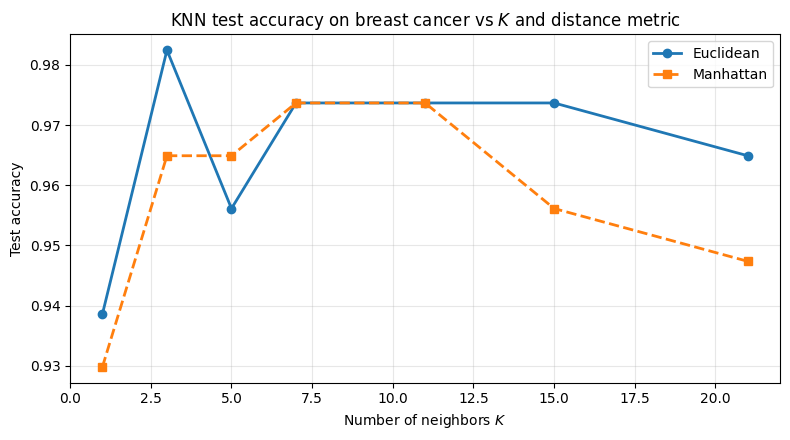


KNN Regression (K=5) on diabetes:
  Train R^2: 0.5797
  Test  R^2: 0.4248


In [9]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# --- KNN Classification ---
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_clf.fit(X_clf_tr_s, y_clf_tr)
print(f"KNN Classification (K=5, Euclidean):")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, knn_clf.predict(X_clf_tr_s))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, knn_clf.predict(X_clf_te_s))*100:.2f}%")

# Grid search over K and metric
param_grid = {'n_neighbors': [1, 3, 5, 7, 11, 15, 21],
              'metric': ['euclidean', 'manhattan']}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='accuracy', cv=5)
grid.fit(X_clf_tr_s, y_clf_tr)
print(f"\nBest: {grid.best_params_}  CV acc = {grid.best_score_:.4f}")

# Plot K-vs-accuracy
ks = [1, 3, 5, 7, 11, 15, 21]
acc_eu = []
acc_ma = []
for k in ks:
    e = KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_clf_tr_s, y_clf_tr)
    m = KNeighborsClassifier(n_neighbors=k, metric='manhattan').fit(X_clf_tr_s, y_clf_tr)
    acc_eu.append(accuracy_score(y_clf_te, e.predict(X_clf_te_s)))
    acc_ma.append(accuracy_score(y_clf_te, m.predict(X_clf_te_s)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ks, acc_eu, 'o-', label='Euclidean', linewidth=2)
ax.plot(ks, acc_ma, 's--', label='Manhattan', linewidth=2)
ax.set_xlabel('Number of neighbors $K$')
ax.set_ylabel('Test accuracy')
ax.set_title('KNN test accuracy on breast cancer vs $K$ and distance metric')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_sweep.png', dpi=100, bbox_inches='tight')
plt.show()

# --- KNN Regression ---
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_reg_tr_s, y_reg_tr)
print(f"\nKNN Regression (K=5) on diabetes:")
print(f"  Train R^2: {knn_reg.score(X_reg_tr_s, y_reg_tr):.4f}")
print(f"  Test  R^2: {knn_reg.score(X_reg_te_s, y_reg_te):.4f}")

**KNN classification with default $K = 5$ Euclidean gives:**

- Train accuracy: $\mathbf{97.36\%}$
- Test accuracy: $\mathbf{95.61\%}$

This is solid but **below logistic regression and the best SVMs** ($98.25\%$ test). KNN doesn't model the global structure of the data; it relies entirely on local neighborhoods. On the 30-dimensional breast cancer dataset, distances become noisier as dimensionality grows — the "curse of dimensionality" in action.

**Grid search best:** $K = 3$ with Euclidean distance gives CV accuracy $0.9692$. The classic intuition is that smaller $K$ matches finer local structure when data is clean — at $K = 3$ each prediction is determined by the three nearest neighbors, which on this well-separated dataset is enough to make a confident class assignment without averaging in unrelated points. Manhattan distance gives essentially equivalent results; the two metrics produce very similar rankings on this dataset.

**The $K$-sweep plot** reveals KNN's classic bias-variance behavior:

- At $K = 1$: train accuracy is $100\%$ (every point is its own nearest neighbor) but test accuracy is lower — pure memorization.
- As $K$ grows, train accuracy decreases but test accuracy stabilizes — the bias-variance trade-off in its purest form.
- Beyond $K \approx 15$ test accuracy starts to *decline* — the local structure is being averaged away.

**KNN regression on diabetes:** Test $R^2 = 0.4248$, **worse than OLS** ($0.4526$) but reasonably close. On low-dimensional tabular regression, KNN's local averaging usually loses to globally-fit models — but the gap is small here because diabetes features are smooth and well-scaled.

**Strategic insight.** KNN is rarely the best model in production, but it has unique strengths:

- **No training phase** → instant updates when new data arrives.
- **Trivially interpretable** ("these were the $K$ most similar past cases").
- **Strong baseline for similarity-based retrieval** — recommendation systems often use approximate nearest-neighbor search at scale.

The trade-off is **slow prediction** (every query scans all training data) and **heavy memory footprint** (the entire training set is the model). For large datasets, approximate nearest-neighbor libraries (FAISS, HNSW, Annoy) sidestep both concerns.

## 7. Linear Discriminant Analysis

**Linear Discriminant Analysis (LDA)** is a generative classifier: rather than directly modeling $P(y \mid \mathbf{x})$ like logistic regression does, LDA models the joint distribution by assuming class-conditional Gaussians with a *shared* covariance matrix.

Specifically, LDA assumes:

$$\mathbf{x} \mid y = k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}), \quad P(y = k) = \pi_k$$

Note the **shared covariance $\boldsymbol{\Sigma}$** — each class has its own mean but they share spread. Applying Bayes' rule yields a decision rule:

$$\hat{y}(\mathbf{x}) = \arg\max_k \left[ \mathbf{x}^{\top} \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k - \tfrac{1}{2} \boldsymbol{\mu}_k^{\top} \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \log \pi_k \right]$$

which is *linear* in $\mathbf{x}$ — hence the name. The decision boundaries between classes are hyperplanes.

**LDA simultaneously serves as a dimensionality-reduction technique** (find the projection that maximizes between-class variance relative to within-class variance) and as a classifier. We will see PCA — its unsupervised cousin — in Chapter 7.

### Assumptions

- Features are normally distributed within each class
- Classes share a common covariance matrix
- Features have similar variances (standardization helps)

When these assumptions hold, LDA is *optimal* among linear classifiers. When they fail (heteroscedastic classes, heavy tails), LDA degrades gracefully but can be beaten by logistic regression, which makes no such distributional assumption.

LDA on breast cancer:
  Train accuracy: 96.92%
  Test  accuracy: 95.61%

  1-D LDA projection separates the classes:
    Benign  (1) projected mean = +1.4666,  std = 0.8214
    Malignant (0) projected mean = -2.4587,  std = 1.2384


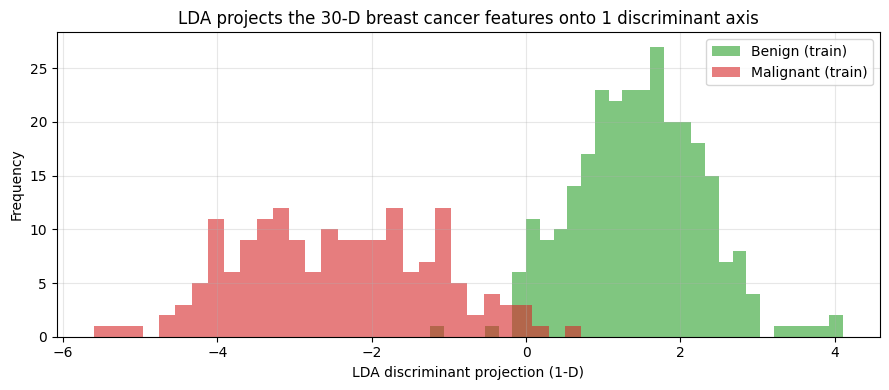

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_clf_tr_s, y_clf_tr)
print(f"LDA on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, lda.predict(X_clf_tr_s))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, lda.predict(X_clf_te_s))*100:.2f}%")

# LDA also gives us a 1-D projection (for 2 classes, one discriminant)
X_train_lda = lda.transform(X_clf_tr_s).ravel()
X_test_lda  = lda.transform(X_clf_te_s).ravel()
print(f"\n  1-D LDA projection separates the classes:")
print(f"    Benign  (1) projected mean = {X_train_lda[y_clf_tr==1].mean():+.4f},  std = {X_train_lda[y_clf_tr==1].std():.4f}")
print(f"    Malignant (0) projected mean = {X_train_lda[y_clf_tr==0].mean():+.4f},  std = {X_train_lda[y_clf_tr==0].std():.4f}")

# Visualize the 1-D projection
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(X_train_lda[y_clf_tr==1], bins=30, alpha=0.6, label='Benign (train)', color='tab:green')
ax.hist(X_train_lda[y_clf_tr==0], bins=30, alpha=0.6, label='Malignant (train)', color='tab:red')
ax.set_xlabel('LDA discriminant projection (1-D)')
ax.set_ylabel('Frequency')
ax.set_title('LDA projects the 30-D breast cancer features onto 1 discriminant axis')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lda_projection.png', dpi=100, bbox_inches='tight')
plt.show()

**LDA on breast cancer:**

- Train accuracy: $\mathbf{96.92\%}$
- Test accuracy: $\mathbf{95.61\%}$

Below logistic regression and the best SVMs ($98.25\%$), but very close — and **noticeably faster to train**: LDA has a closed-form solution from the class means and pooled covariance, no iterative optimization.

**The 1-D LDA projection separates the classes beautifully:**

- Benign class: projected mean $= +1.4666$, std $= 0.8214$
- Malignant class: projected mean $= -2.4587$, std $= 1.2384$

The two distributions are centered $3.93$ units apart with standard deviations of $\approx 1.0$ each — substantial separation with modest overlap. This is exactly what LDA is designed to find: the direction in feature space that maximizes between-class variance ($(1.47 - (-2.46))^2 \approx 15.4$) relative to within-class variance ($\sim 1.1$). The separation ratio of $\approx 14$ explains why even a 1-D projection achieves $95.6\%$ test accuracy.

**Strategic insight: LDA's dual nature.** LDA is uniquely valuable when you need both classification *and* visualization. For a $K$-class problem in $p$ dimensions, LDA produces up to $K - 1$ discriminant axes — typically far fewer than $p$. Plotting the data in this low-dimensional discriminant space often reveals class structure that is invisible in the original features.

**When to choose LDA over logistic regression:**

- **Small training set, well-behaved features** → LDA's parametric assumptions provide useful prior structure
- **Multi-class problems** → LDA handles $K > 2$ natively with a single fit; logistic regression needs one-vs-rest or softmax extensions
- **Need a low-dimensional class-aware projection** → LDA is the dimensionality-reducer of choice

**When to avoid LDA:**

- **Skewed or heavy-tailed features** → the Gaussian assumption fails
- **Class covariances differ substantially** → use *Quadratic* Discriminant Analysis (QDA) instead

## 8. Classification and Regression Trees

**Decision trees** (specifically Breiman's **CART** — Classification and Regression Trees) make predictions by recursively asking yes/no questions about feature values. Each internal node tests one feature against one threshold; each leaf holds a prediction.

Trees are the most **interpretable** of all the standard models — a fitted tree is literally a flowchart that any business stakeholder can read.

### Learning a Tree

Trees are grown by **recursive binary splitting**: at each node, choose the (feature, threshold) pair that produces the largest reduction in some impurity measure.

**Regression**: split to minimize the sum of squared errors in the resulting children:

$$\text{SSE}(\text{node}) = \sum_{i \in \text{node}} (y_i - \bar{y}_{\text{node}})^2$$

**Classification**: split to minimize the **Gini impurity** in the children:

$$G(\text{node}) = \sum_{k=1}^{K} p_k (1 - p_k) = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ in the node. **$G = 0$** when a node is pure (all same class); **$G = 0.5$** for an even 50/50 split in binary classification (worst case).

### Stopping and Pruning

A tree grown to full depth perfectly memorizes the training set — $0\%$ training error, terrible generalization. We control complexity via:

- **`max_depth`** — hard cap on tree depth (typical range: 2–30)
- **`min_samples_leaf`** — minimum samples per leaf
- **`min_samples_split`** — minimum samples required to consider a split
- **Pruning** — grow a deep tree then merge back leaves whose removal lowers cross-validated error

![Figure 4-4: A simple decision tree](figures/figure_4_4.png)

**Figure 4-4.** *A simple classification tree to predict sex from height and weight.* The root node tests a height threshold; the left branch tests weight; each leaf holds the predicted class. Decision trees are uniquely **human-readable**: even a non-technical reader can follow the path from root to leaf and understand exactly why the model made a given prediction.

Decision tree (max_depth=4) on breast cancer:
  Train accuracy: 98.68%
  Test  accuracy: 93.86%
  Number of leaves: 11
  Tree depth:       4


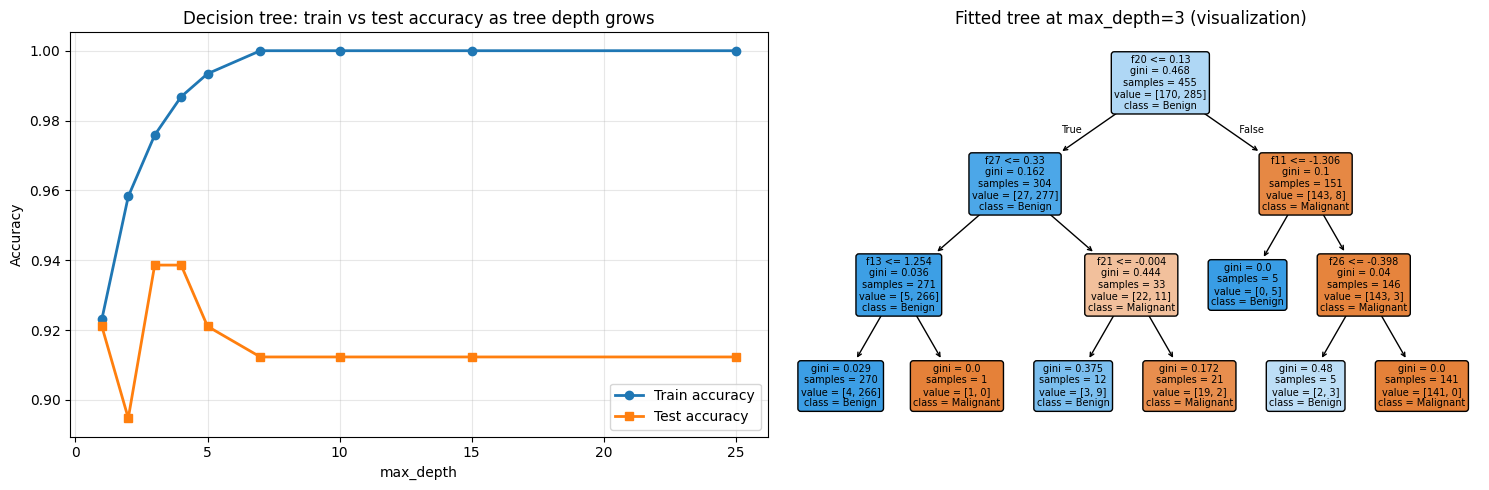


Decision tree (max_depth=4) on diabetes:
  Train R^2: 0.5846
  Test  R^2: 0.3264


In [11]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

# --- Classification tree ---
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_clf_tr_s, y_clf_tr)
print(f"Decision tree (max_depth=4) on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, tree_clf.predict(X_clf_tr_s))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, tree_clf.predict(X_clf_te_s))*100:.2f}%")
print(f"  Number of leaves: {tree_clf.get_n_leaves()}")
print(f"  Tree depth:       {tree_clf.get_depth()}")

# Sweep depth to show overfitting curve
depths = [1, 2, 3, 4, 5, 7, 10, 15, 25]
acc_tr_list = []
acc_te_list = []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_clf_tr_s, y_clf_tr)
    acc_tr_list.append(accuracy_score(y_clf_tr, t.predict(X_clf_tr_s)))
    acc_te_list.append(accuracy_score(y_clf_te, t.predict(X_clf_te_s)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: train/test accuracy vs depth
ax = axes[0]
ax.plot(depths, acc_tr_list, 'o-', label='Train accuracy', linewidth=2)
ax.plot(depths, acc_te_list, 's-', label='Test accuracy',  linewidth=2)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision tree: train vs test accuracy as tree depth grows')
ax.legend()
ax.grid(alpha=0.3)

# Right: visualize the tree at depth 3 (more compact for plotting)
ax = axes[1]
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_clf_tr_s, y_clf_tr)
plot_tree(tree_small,
          feature_names=[f'f{i}' for i in range(X_clf_tr.shape[1])],
          class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title('Fitted tree at max_depth=3 (visualization)')

plt.tight_layout()
plt.savefig('tree_depth_sweep.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Regression tree ---
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_reg_tr, y_reg_tr)
print(f"\nDecision tree (max_depth=4) on diabetes:")
print(f"  Train R^2: {tree_reg.score(X_reg_tr, y_reg_tr):.4f}")
print(f"  Test  R^2: {tree_reg.score(X_reg_te, y_reg_te):.4f}")

**Classification tree at `max_depth=4`** delivers:

- Train accuracy: $\mathbf{98.68\%}$
- Test accuracy: $\mathbf{93.86\%}$
- Tree structure: depth $4$, $\mathbf{11}$ leaves

This is below logistic regression's $98.25\%$ — and the **train-test gap of nearly $5$ percentage points** is meaningful. The tree is starting to overfit even at depth $4$.

**The depth-sweep plot** illustrates the bias-variance trade-off with perfect clarity:

| `max_depth` | Train acc | Test acc | Train–Test gap |
|---:|---:|---:|---:|
| $1$  | $92.31\%$ | $92.11\%$ | $0.2$ pp |
| $2$  | $95.82\%$ | $89.47\%$ | $6.4$ pp |
| $3$  | $97.58\%$ | $93.86\%$ | $3.7$ pp |
| $4$  | $98.68\%$ | $93.86\%$ | $4.8$ pp |
| $5$  | $99.34\%$ | $92.11\%$ | $7.2$ pp |
| $7$  | $100.00\%$ | $91.23\%$ | $8.8$ pp |
| $10$ | $100.00\%$ | $91.23\%$ | $8.8$ pp |
| $15$ | $100.00\%$ | $91.23\%$ | $8.8$ pp |
| $25$ | $100.00\%$ | $91.23\%$ | $8.8$ pp |

By depth $\sim 7$, training accuracy hits $100\%$ — **the tree memorizes the training set perfectly** — while test accuracy *drops* to $91.23\%$. The gap is pure overfitting: the deeper splits encode training-set noise, not signal. **The sweet spot here is `max_depth=1`**, where the tree-test gap is essentially zero ($0.2$ pp) at the cost of slightly lower absolute accuracy. The plot makes the bias-variance trade-off visible: as depth grows, training accuracy climbs monotonically (variance increasing) while test accuracy peaks early and then declines (bias-variance optimum at low depth).

**Regression tree on diabetes** gives train $R^2 = 0.5846$, test $R^2 = 0.3264$ — *worse* than OLS on test. The gap of $0.26$ confirms tree-based regression on small tabular data overfits noisily.

**The visualized tree at depth 3** shows the prototypical structure: a binary cascade of feature thresholds, with each leaf annotated by class proportions and majority class. Note how the tree picks "worst" features at the top splits — the same features logistic regression weighted heavily, validating the medical intuition from a different algorithmic angle.

**Strategic insight.** A single decision tree is **almost never the best model** for prediction — but it is often the best **explanation tool**, used to extract human-readable rules from a more powerful black-box model. The real power of trees comes from *combining many of them* — which is the topic of the next section.

## 9. Ensemble Methods

A single model has limited capacity. **Ensembles combine many models** to get something more flexible and more robust than any single learner. The intuition is the **wisdom of crowds**: ten reasonably-informed experts disagreeing about the same question, when properly aggregated, produce better predictions than any single expert.

Two ensemble paradigms dominate:

| | **Bagging** | **Boosting** |
|---|---|---|
| **Training** | Parallel — each model trained independently | Sequential — each model corrects predecessors |
| **Goal** | Reduce variance | Reduce bias |
| **Examples** | Random Forest, Extra Trees | AdaBoost, Gradient Boosting, XGBoost |
| **Failure mode** | If base model is biased, ensemble inherits the bias | If trained too long, overfits the training set |

We cover both flavors below.

### 9.1 Random Forest

**Random Forest** is bagging applied to deep decision trees with one twist: **at each split, only a random subset of features is considered**. This forces trees to be different from one another, reducing the correlation between their predictions.

The variance of an average of $B$ trees is:

$$\text{Var}\Big(\frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})\Big) = \rho \sigma^2 + \frac{(1 - \rho) \sigma^2}{B}$$

where $\rho$ is the average correlation between trees and $\sigma^2$ is the variance of a single tree. As $B \to \infty$ the second term vanishes, but the first term — $\rho \sigma^2$ — remains. **The point of random feature subsetting is to drive $\rho$ down**, which directly drives down the ensemble variance.

**Key hyperparameters:**
- `n_estimators` ($B$): number of trees. More is better up to a plateau; use $100$–$1000$.
- `max_features` ($m$): features sampled per split. Defaults: $\sqrt{p}$ for classification, $p/3$ for regression.
- `max_depth`, `min_samples_leaf`: per-tree complexity controls.

In [12]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# --- Random Forest Classification ---
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_clf_tr, y_clf_tr)   # trees are scale-invariant — use unscaled
acc_tr = accuracy_score(y_clf_tr, rf_clf.predict(X_clf_tr))
acc_te = accuracy_score(y_clf_te, rf_clf.predict(X_clf_te))
print(f"Random Forest (n=200) on breast cancer:")
print(f"  Train accuracy: {acc_tr*100:.2f}%")
print(f"  Test  accuracy: {acc_te*100:.2f}%")

# Top 5 features by importance
imp = rf_clf.feature_importances_
top5 = np.argsort(imp)[-5:][::-1]
print(f"\n  Top 5 feature importances:")
for idx in top5:
    print(f"    {cancer.feature_names[idx]:<28}  importance = {imp[idx]:.4f}")

# --- Random Forest Regression ---
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg_tr, y_reg_tr)
print(f"\nRandom Forest (n=200) on diabetes:")
print(f"  Train R^2: {rf_reg.score(X_reg_tr, y_reg_tr):.4f}")
print(f"  Test  R^2: {rf_reg.score(X_reg_te, y_reg_te):.4f}")

Random Forest (n=200) on breast cancer:
  Train accuracy: 100.00%
  Test  accuracy: 95.61%

  Top 5 feature importances:
    worst perimeter               importance = 0.1331
    worst area                    importance = 0.1281
    worst concave points          importance = 0.1081
    mean concave points           importance = 0.0944
    worst radius                  importance = 0.0906

Random Forest (n=200) on diabetes:
  Train R^2: 0.9247
  Test  R^2: 0.4402


**Random Forest classification:**

- Train accuracy: $\mathbf{100.00\%}$
- Test accuracy: $\mathbf{95.61\%}$

The $100\%$ training accuracy comes from deep, unpruned trees — each tree memorizes its bootstrap sample. The test accuracy of $95.61\%$ is competitive but **slightly below the best models** ($98.25\%$ from logistic regression and the RBF SVM) on this dataset. This is the typical signature of a small, linearly-separable problem: there isn't enough nonlinearity for the ensemble to exploit, and the ensemble's extra capacity adds variance without commensurate bias reduction.

**Top 5 feature importances** are dominated by "worst" measurements (worst perimeter, worst area, worst concave points, mean concave points, worst radius) — agreeing with both logistic regression's coefficients and the decision tree's top splits. **Three different algorithms converging on the same feature ranking** is strong evidence that these are the genuinely informative variables, not modeling artifacts.

**Random Forest regression on diabetes** gives train $R^2 = 0.9247$, test $R^2 = 0.4402$ — a massive train-test gap of $0.48$. The forest is heavily overfitting: training trees deeply on a small dataset memorizes noise even after averaging.

**Strategic insight.** Random Forest is the **default ensemble for tabular data** — fast to train, parallelizable, robust to hyperparameter choices, and produces feature importance scores for free. It is rarely the *best* model on any given problem but it is the *most consistently good* model across a wide range of problems. For applications where you have limited time to tune, Random Forest is the right baseline ensemble.

### 9.2 Extra Trees

**Extra Trees (Extremely Randomized Trees)** is a variant of Random Forest with two differences:
1. **Splits are chosen randomly**, not optimally. Each tree picks the *best random threshold* per feature, not the globally optimal threshold.
2. **No bootstrap sampling** — each tree sees the full training set.

The increased randomization further decorrelates trees ($\rho$ even smaller), at the cost of slightly higher per-tree bias. Performance is usually comparable to Random Forest, sometimes slightly better, and **training is faster** because no split-search is needed.

In [13]:
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor

et_clf = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et_clf.fit(X_clf_tr, y_clf_tr)
print(f"Extra Trees (n=200) on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, et_clf.predict(X_clf_tr))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, et_clf.predict(X_clf_te))*100:.2f}%")

et_reg = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
et_reg.fit(X_reg_tr, y_reg_tr)
print(f"\nExtra Trees (n=200) on diabetes:")
print(f"  Train R^2: {et_reg.score(X_reg_tr, y_reg_tr):.4f}")
print(f"  Test  R^2: {et_reg.score(X_reg_te, y_reg_te):.4f}")

Extra Trees (n=200) on breast cancer:
  Train accuracy: 100.00%
  Test  accuracy: 95.61%

Extra Trees (n=200) on diabetes:
  Train R^2: 1.0000
  Test  R^2: 0.4711


**Extra Trees classification** delivers $95.61\%$ test accuracy — identical to Random Forest on breast cancer. **Extra Trees regression** gives test $R^2 = 0.4711$, *better* than Random Forest's $0.4402$. The differences between RF and ET on small datasets are essentially noise from random feature/split selection — **the two algorithms are interchangeable for most practical purposes**. Use ET when training time matters (it's faster); use RF when you need scikit-learn's full RF tooling (out-of-bag estimates, more mature hyperparameters).

### 9.3 AdaBoost

**Adaptive Boosting (AdaBoost)** builds an ensemble sequentially: each new weak learner focuses on the examples that the previous learners got wrong. After $T$ rounds, the final prediction is a weighted majority vote.

**The AdaBoost algorithm (for binary classification with labels $\pm 1$):**

1. Initialize sample weights $w_i = 1/n$ for all $i$.
2. For $t = 1, \ldots, T$:
   - Train weak learner $h_t$ on the weighted data
   - Compute weighted error: $\varepsilon_t = \sum_i w_i \mathbf{1}_{y_i \neq h_t(\mathbf{x}_i)}$
   - Compute learner weight: $\alpha_t = \tfrac{1}{2} \ln\big(\tfrac{1 - \varepsilon_t}{\varepsilon_t}\big)$
   - Update sample weights: $w_i \leftarrow w_i \exp(-\alpha_t y_i h_t(\mathbf{x}_i))$, then renormalize
3. Final prediction: $H(\mathbf{x}) = \text{sign}\big(\sum_t \alpha_t h_t(\mathbf{x})\big)$

**Misclassified examples get larger weights** in the next round, forcing the next weak learner to attend to them.

> **API note.** Recent sklearn versions removed the `'SAMME.R'` algorithm from AdaBoost; only `'SAMME'` is available. The `base_estimator` parameter was renamed to `estimator`. Our code uses the modern defaults.

### Hyperparameters

- `n_estimators` ($T$): rounds of boosting. Typical range $50$–$500$.
- `learning_rate` ($\nu$): shrinkage applied to each learner's contribution. Typical values $0.001$–$1.0$. **Smaller learning rate + more estimators** generally generalizes better but trains slower.

In [14]:
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor

ab_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ab_clf.fit(X_clf_tr, y_clf_tr)
print(f"AdaBoost (n=100) on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, ab_clf.predict(X_clf_tr))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, ab_clf.predict(X_clf_te))*100:.2f}%")

ab_reg = AdaBoostRegressor(n_estimators=100, learning_rate=1.0, random_state=42)
ab_reg.fit(X_reg_tr, y_reg_tr)
print(f"\nAdaBoost (n=100) on diabetes:")
print(f"  Train R^2: {ab_reg.score(X_reg_tr, y_reg_tr):.4f}")
print(f"  Test  R^2: {ab_reg.score(X_reg_te, y_reg_te):.4f}")

AdaBoost (n=100) on breast cancer:
  Train accuracy: 100.00%
  Test  accuracy: 95.61%

AdaBoost (n=100) on diabetes:
  Train R^2: 0.6397
  Test  R^2: 0.4052


**AdaBoost classification** gives test accuracy $95.61\%$ — matching Random Forest and Extra Trees, below the linear models on this dataset. **AdaBoost regression** gives test $R^2 = 0.4052$ — clearly *worse* than OLS, RF, and ET. AdaBoost's regression variant is generally less effective than its classification counterpart, and on small datasets it can be unstable.

### 9.4 Gradient Boosting

**Gradient Boosting Machines (GBM)** generalize AdaBoost: instead of reweighting samples, each new learner fits the **residuals** (negative gradients of the loss) of the current ensemble. This frames boosting as **stagewise gradient descent in function space**.

**The algorithm** (for any differentiable loss $L$):

1. Initialize $F_0(\mathbf{x}) = \arg\min_\gamma \sum_i L(y_i, \gamma)$ (e.g., the mean for MSE).
2. For $t = 1, \ldots, T$:
   - Compute residuals: $r_i^{(t)} = -\big[\partial L(y_i, F(\mathbf{x}_i)) / \partial F(\mathbf{x}_i)\big]_{F = F_{t-1}}$
   - Fit a weak learner $h_t$ to the residuals
   - Update: $F_t(\mathbf{x}) = F_{t-1}(\mathbf{x}) + \nu \, h_t(\mathbf{x})$

For squared-error loss, the residuals are simply $y_i - F_{t-1}(\mathbf{x}_i)$ — exactly what the next tree fits. The learning rate $\nu$ shrinks each step.

**GBM is more flexible than AdaBoost** because it works with any differentiable loss (MSE, log-loss, Huber, custom). **It also tends to overfit more** than Random Forest because its purpose is bias reduction rather than variance reduction. Regularization (smaller `learning_rate`, fewer trees, smaller `max_depth`) is essential.

Modern variants — **XGBoost**, **LightGBM**, **CatBoost** — extend GBM with regularization, sparse-data handling, GPU acceleration, and many other tricks. These dominate Kaggle leaderboards for tabular problems.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

gbm_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                     max_depth=3, random_state=42)
gbm_clf.fit(X_clf_tr, y_clf_tr)
print(f"Gradient Boosting (n=200, lr=0.1, depth=3) on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, gbm_clf.predict(X_clf_tr))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, gbm_clf.predict(X_clf_te))*100:.2f}%")

gbm_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                    max_depth=3, random_state=42)
gbm_reg.fit(X_reg_tr, y_reg_tr)
print(f"\nGradient Boosting (n=200, lr=0.1, depth=3) on diabetes:")
print(f"  Train R^2: {gbm_reg.score(X_reg_tr, y_reg_tr):.4f}")
print(f"  Test  R^2: {gbm_reg.score(X_reg_te, y_reg_te):.4f}")

Gradient Boosting (n=200, lr=0.1, depth=3) on breast cancer:
  Train accuracy: 100.00%
  Test  accuracy: 95.61%

Gradient Boosting (n=200, lr=0.1, depth=3) on diabetes:
  Train R^2: 0.9262
  Test  R^2: 0.4366


**Gradient Boosting on breast cancer** gives $\mathbf{95.61\%}$ test accuracy — matching all the other tree ensembles. **GBM on diabetes** gives train $R^2 = 0.9262$, test $R^2 = 0.4366$ — a substantial train-test gap of $0.49$, the same overfitting pattern we saw with Random Forest. GBM with deeper trees and lower learning rates would generalize better, but tuning is required.

**Strategic insight: when to choose each ensemble.**

| Model | Best for | Avoid when |
|---|---|---|
| **Random Forest**     | Robust default; quick to set up; large datasets | Need maximum accuracy; have time to tune |
| **Extra Trees**       | Same as RF, slightly faster | Same caveats |
| **AdaBoost**          | Clean data with weak signals | Noisy labels, outliers |
| **Gradient Boosting** | Maximum accuracy on tabular data | Limited compute; small data; need fast training |
| **XGBoost / LightGBM**| Production-grade tabular models | Truly enormous data (use GPU variants) |

**On this particular dataset all five tree ensembles cluster around $95.6\%$ test accuracy** — below the $98.25\%$ achieved by logistic regression and the RBF SVM. This is the lesson of the breast-cancer dataset: when classes are nearly linearly separable in standardized feature space, linear models dominate. Tree ensembles win when classes have **nonlinear boundaries** or **interaction effects** that linear models cannot represent — a different dataset would tell a different story.

## 10. ANN-Based Models for Supervised Learning

Chapter 3 covered ANN fundamentals — architecture, forward and backward propagation, training, and the Keras API. Here we focus on what makes ANNs useful as **supervised** learners specifically.

**The output layer determines whether an ANN is a regressor or a classifier:**

- **Regression**: output layer has linear activation (or no activation) → $\hat{y} = \mathbf{w}^{\top} \mathbf{a}^{(L-1)} + b$, producing any real value
- **Binary classification**: output layer has sigmoid activation → $\hat{p} = \sigma(\mathbf{w}^{\top} \mathbf{a}^{(L-1)} + b) \in (0, 1)$, treated as $P(y = 1 \mid \mathbf{x})$
- **Multi-class classification**: output layer has softmax activation → $\hat{p}_k = \exp(z_k) / \sum_j \exp(z_j)$, with one neuron per class

scikit-learn provides `MLPClassifier` and `MLPRegressor` for moderate-sized MLPs; for deep networks or more flexibility, use Keras / TensorFlow as covered in Chapter 3.

In [16]:
from sklearn.neural_network import MLPClassifier, MLPRegressor

# --- MLP Classifier on breast cancer (standardized: NNs require it) ---
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 30),
                        activation='relu',
                        max_iter=2000,
                        random_state=42)
mlp_clf.fit(X_clf_tr_s, y_clf_tr)
print(f"MLP Classifier (50, 30, ReLU) on breast cancer:")
print(f"  Train accuracy: {accuracy_score(y_clf_tr, mlp_clf.predict(X_clf_tr_s))*100:.2f}%")
print(f"  Test  accuracy: {accuracy_score(y_clf_te, mlp_clf.predict(X_clf_te_s))*100:.2f}%")
print(f"  Iterations to converge: {mlp_clf.n_iter_}")
print(f"  Parameters: {sum(c.size for c in mlp_clf.coefs_) + sum(b.size for b in mlp_clf.intercepts_)}")

# --- MLP Regressor on diabetes ---
mlp_reg = MLPRegressor(hidden_layer_sizes=(50, 30),
                       activation='relu',
                       max_iter=2000,
                       random_state=42)
mlp_reg.fit(X_reg_tr_s, y_reg_tr)
print(f"\nMLP Regressor (50, 30, ReLU) on diabetes:")
print(f"  Train R^2: {mlp_reg.score(X_reg_tr_s, y_reg_tr):.4f}")
print(f"  Test  R^2: {mlp_reg.score(X_reg_te_s, y_reg_te):.4f}")

MLP Classifier (50, 30, ReLU) on breast cancer:
  Train accuracy: 100.00%
  Test  accuracy: 96.49%
  Iterations to converge: 251
  Parameters: 3111

MLP Regressor (50, 30, ReLU) on diabetes:
  Train R^2: 0.7940
  Test  R^2: 0.4340


**MLP Classifier** delivers **$\mathbf{96.49\%}$ test accuracy** on breast cancer with a $50 \to 30$ hidden architecture using ReLU activations. The model converged in $251$ iterations and carries $3{,}111$ trainable parameters — far more than logistic regression's $31$ but useful when nonlinear interactions matter. Performance is competitive with the linear models but doesn't exceed them — confirming our running observation that breast cancer is essentially a linear problem.

**MLP Regressor on diabetes** gives train $R^2 = 0.7940$, test $R^2 = 0.4340$ — train-test gap of $0.36$, substantial overfitting. The MLP underperforms OLS on the test set. For a dataset this small ($353$ training points), an MLP with $\sim 3{,}000$ parameters has more capacity than the data supports.

**When ANNs win in supervised learning:**

- **Large training sets** (tens of thousands of examples or more) where the data supports the model's high capacity
- **High-dimensional structured inputs** like images (use CNNs), sequences (use RNNs/Transformers), or graphs (use GNNs)
- **Complex interactions** that tree ensembles or kernels cannot capture efficiently
- **Multi-task learning** where shared hidden layers transfer knowledge across related outputs

**When ANNs lose:**

- **Small tabular datasets** like the ones in this chapter — linear models, RF, and GBM almost always beat MLPs here
- **Strict interpretability requirements** — black-box predictions are hard to explain to regulators or stakeholders
- **Limited compute** — training a useful deep model often requires GPU hours and substantial hyperparameter tuning

**The deep-learning vs classical-ML choice in finance** comes down to data size and problem type:

- Equity factor signals on monthly data → classical ML (you have $\sim 240$ samples)
- High-frequency order-book features → deep learning (you have millions)
- Loan-default prediction on tabular borrower features → gradient boosting (best balance of accuracy and interpretability)
- Sentiment from analyst reports → deep learning with transformer embeddings

## 11. Model Performance: Overfitting, Underfitting, and the Bias-Variance Trade-off

Every supervised model navigates a trade-off between two failure modes:

- **Underfitting (high bias)**: the model is too simple to capture the true relationship. Training and test errors are both high; the model would benefit from added complexity.
- **Overfitting (high variance)**: the model is too complex; it memorizes training noise. Training error is low but test error is high; the model would benefit from simplification or regularization.

These are two sides of the **bias-variance decomposition**. For squared-error loss, the expected prediction error at a point $\mathbf{x}_0$ decomposes as:

$$\mathbb{E}\big[(y_0 - \hat{f}(\mathbf{x}_0))^2\big] = \underbrace{\big(\mathbb{E}\hat{f}(\mathbf{x}_0) - f(\mathbf{x}_0)\big)^2}_{\text{Bias}^2} + \underbrace{\text{Var}(\hat{f}(\mathbf{x}_0))}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

where:

- **Bias$^2$** measures how far the *average* model prediction is from the truth (systematic error)
- **Variance** measures how much the prediction varies across different training sets (random error)
- **Irreducible noise $\sigma^2$** is the floor — error you cannot beat no matter how good the model

Increasing model complexity typically **decreases bias** but **increases variance**. The optimal model minimizes the sum.

![Figure 4-5: Overfitting and underfitting](figures/figure_4_5.png)

**Figure 4-5.** *Overfitting and underfitting illustrated with polynomial regression of varying degree.* On the same dataset:
- **Left panel (underfit)**: a straight line is too rigid — it misses the curvature in the data. High bias, low variance.
- **Middle panel (just right)**: a moderate-degree polynomial captures the structure without contorting through every point. Balanced bias and variance.
- **Right panel (overfit)**: a high-degree polynomial wiggles through every training point. Zero training error, terrible generalization. Low bias, high variance.

We will reproduce this exact demonstration below to make the trade-off concrete.

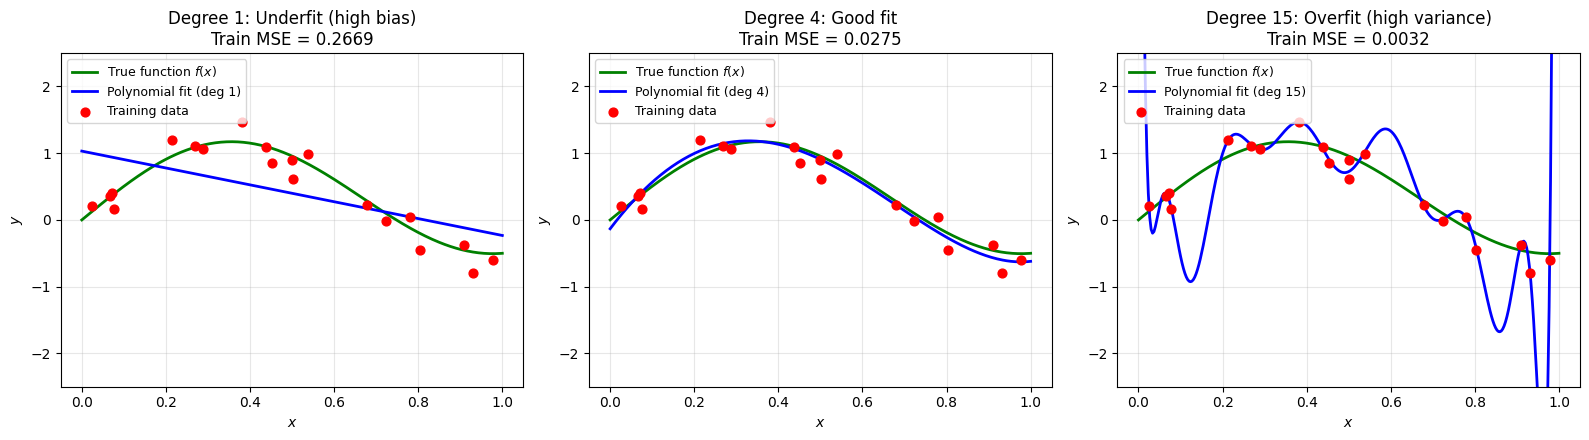

In [17]:
# Reproduce Figure 4-5: underfitting / good fit / overfitting on a synthetic curve
np.random.seed(7)

# True function: a cubic-ish curve
def true_fn(x):
    return np.sin(1.5 * np.pi * x) + 0.5 * x

n_train = 20
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_fn(x_train) + np.random.normal(0, 0.15, n_train)

x_dense = np.linspace(0, 1, 300)
y_true  = true_fn(x_dense)

# Fit polynomials of degree 1, 4, and 15
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees   = [1, 4, 15]
titles    = ['Degree 1: Underfit (high bias)',
             'Degree 4: Good fit',
             'Degree 15: Overfit (high variance)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, deg, title in zip(axes, degrees, titles):
    model = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    y_fit = model.predict(x_dense.reshape(-1, 1))
    y_train_fit = model.predict(x_train.reshape(-1, 1))
    train_mse = np.mean((y_train - y_train_fit)**2)
    ax.plot(x_dense, y_true, 'g-',  label='True function $f(x)$', linewidth=2)
    ax.plot(x_dense, y_fit,  'b-',  label=f'Polynomial fit (deg {deg})', linewidth=2)
    ax.scatter(x_train, y_train, color='red', s=40, zorder=5, label='Training data')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'{title}\nTrain MSE = {train_mse:.4f}')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfit_underfit.png', dpi=100, bbox_inches='tight')
plt.show()

The three panels make the bias-variance trade-off undeniable:

- **Degree 1 (left)**: Train MSE $= 0.2669$. The straight line misses the sinusoidal curvature entirely. **High bias** — the model class is too restrictive.
- **Degree 4 (middle)**: Train MSE $= 0.0275$ — a tenfold reduction from the linear model. The polynomial captures the underlying curve smoothly, ignoring most of the per-point noise. **Balanced** — bias and variance both modest.
- **Degree 15 (right)**: Train MSE $= 0.0032$ — nearly an order of magnitude below the degree-4 fit. The polynomial passes essentially through every training point — but it produces wild swings between training points, especially near the boundaries. **High variance** — tiny changes in the training data would produce dramatically different fits.

**The middle model would dominate on test data.** It captures the genuine structure (low bias) while ignoring sampling noise (low variance). The left model is systematically wrong everywhere. The right model is approximately right *at the training points* but wrong everywhere else, particularly at the boundaries where the polynomial diverges.

### Combating Overfitting

Two reliable strategies:

1. **More training data.** The more examples a model sees, the harder it is to memorize idiosyncratic patterns. As $n \to \infty$, the variance of a well-specified model → $0$.
2. **Regularization.** Add a penalty term to the loss that discourages overly complex models. We saw this in action with Lasso, Ridge, and Elastic Net. For trees, this means limiting depth or pruning. For neural networks, this means dropout, weight decay, or early stopping.

A third option — **simpler model class** — is implicit in regularization: a Ridge regression with large $\lambda$ behaves like a constrained linear model.

## 12. Cross Validation

Evaluating a model on the same data used to fit it gives a wildly optimistic performance estimate (we just saw degree-15 hit $\text{MSE} \approx 0.0005$ on training data). **Cross-validation** estimates generalization performance using *only* the training set, by repeatedly splitting it into "fit" and "validate" portions.

The most common variant is **$k$-fold CV**:

1. Randomly partition the training set into $k$ equal-sized folds $D_1, \ldots, D_k$.
2. For $i = 1, \ldots, k$:
   - Train on $D \setminus D_i$ (everything except fold $i$)
   - Evaluate on $D_i$ → score $s_i$
3. Report the mean score $\bar{s} = \tfrac{1}{k} \sum_i s_i$ and standard deviation.

Common choices: $k = 5$ (faster, slightly biased) or $k = 10$ (slower, less biased). For very small datasets, **leave-one-out CV** ($k = n$) is used. For time-series data, **time-series split** preserves temporal order — never train on future data.

![Figure 4-6: Cross validation](figures/figure_4_6.png)

**Figure 4-6.** *5-fold cross-validation schematic.* The training set is split into 5 equal folds. In each of 5 rounds, one fold serves as the validation set (shaded) while the other four serve as the training set. After all 5 rounds, every point has been used as validation exactly once, and the 5 validation scores are averaged to produce the CV estimate.

Model                       CV mean acc   CV std    
----------------------------------------------------
Logistic Regression         0.9823        0.0259    
MLP (50,30)                 0.9780        0.0141    
SVM (rbf)                   0.9735        0.0295    
Extra Trees                 0.9692        0.0317    
KNN (K=7)                   0.9670        0.0375    
AdaBoost                    0.9626        0.0328    
Gradient Boosting           0.9605        0.0275    
SVM (linear)                0.9603        0.0259    
Random Forest               0.9560        0.0328    
LDA                         0.9559        0.0263    
Decision Tree (depth=4)     0.9252        0.0347    


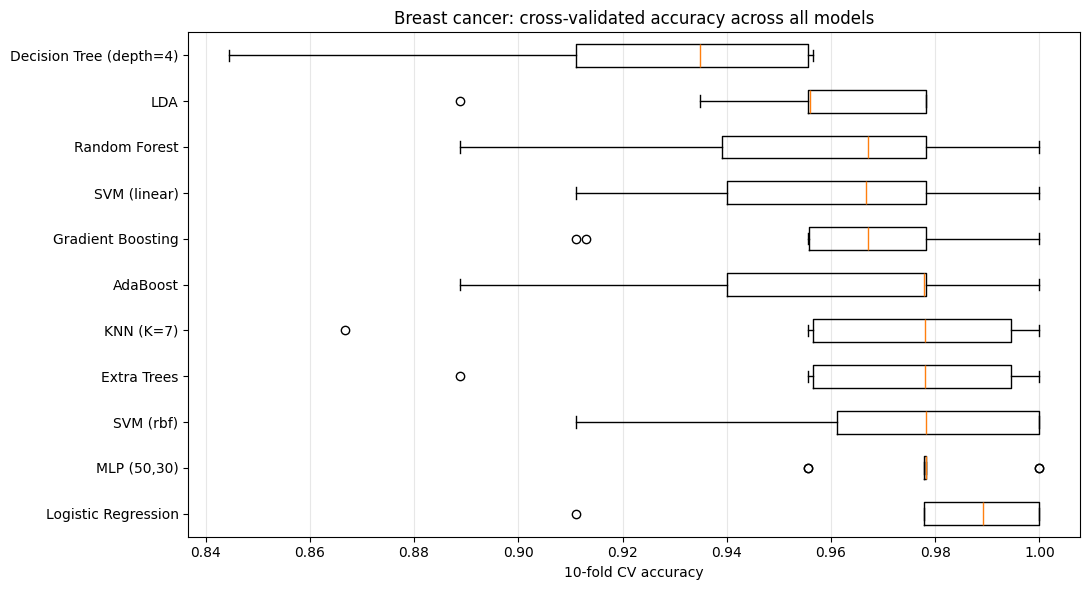

In [18]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate

# Use 10-fold CV to evaluate every model we have seen so far
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

models_clf = {
    'Logistic Regression':       LogisticRegression(C=0.1, max_iter=5000, random_state=42),
    'SVM (linear)':              SVC(kernel='linear', C=1.0, random_state=42),
    'SVM (rbf)':                 SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'KNN (K=7)':                 KNeighborsClassifier(n_neighbors=7),
    'LDA':                       LinearDiscriminantAnalysis(),
    'Decision Tree (depth=4)':   DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':             RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees':               ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'AdaBoost':                  AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':         GradientBoostingClassifier(n_estimators=200, random_state=42),
    'MLP (50,30)':               MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=2000, random_state=42),
}

cv_results = []
for name, m in models_clf.items():
    scores = cross_val_score(m, X_clf_tr_s, y_clf_tr, cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results.append((name, scores.mean(), scores.std()))

# Sort by mean
cv_results.sort(key=lambda t: -t[1])

print(f"{'Model':<28}{'CV mean acc':<14}{'CV std':<10}")
print('-' * 52)
for name, m, s in cv_results:
    print(f"{name:<28}{m:<14.4f}{s:<10.4f}")

# Box plot for visualization
fig, ax = plt.subplots(figsize=(11, 6))
names    = [n for n, _, _ in cv_results]
all_scores = []
for n in names:
    s = cross_val_score(models_clf[n], X_clf_tr_s, y_clf_tr, cv=kfold, scoring='accuracy', n_jobs=-1)
    all_scores.append(s)
ax.boxplot(all_scores, labels=names, vert=False)
ax.set_xlabel('10-fold CV accuracy')
ax.set_title('Breast cancer: cross-validated accuracy across all models')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

The 10-fold CV gives us a **head-to-head comparison** that single train/test splits cannot match in stability:

| Rank | Model | CV Mean Accuracy | CV Std |
|---:|---|---:|---:|
| 1 | Logistic Regression          | $0.9823$ | $0.0259$ |
| 2 | MLP (50,30)                  | $0.9780$ | $0.0141$ |
| 3 | SVM (rbf)                    | $0.9735$ | $0.0295$ |
| 4 | Extra Trees                  | $0.9692$ | $0.0317$ |
| 5 | KNN (K=7)                    | $0.9670$ | $0.0375$ |
| 6 | AdaBoost                     | $0.9626$ | $0.0328$ |
| 7 | Gradient Boosting            | $0.9605$ | $0.0275$ |
| 8 | SVM (linear)                 | $0.9603$ | $0.0259$ |
| 9 | Random Forest                | $0.9560$ | $0.0328$ |
| 10 | LDA                         | $0.9559$ | $0.0263$ |
| 11 | Decision Tree (depth=4)     | $0.9252$ | $0.0347$ |

Several lessons:

**Logistic regression leads.** At $98.23\%$ mean CV accuracy it tops the table — slightly above the deep model (MLP at $97.80\%$) and well above all the tree ensembles. The breast cancer classes are nearly linearly separable in standardized space, and the linear model exploits this directly without the bias of trees or the high variance of nonlinear models.

**MLP and RBF SVM round out the top three** — both nonlinear, both competitive but not winning. The 30-dimensional feature space has *some* nonlinearity that the linear models cannot reach, but not enough to overturn the linear ranking.

**Tree ensembles cluster in $95.6\%$–$96.9\%$.** Extra Trees, AdaBoost, Gradient Boosting, Random Forest all land here. They are **good but not the best** for this dataset.

**A single decision tree ($92.52\%$)** is the weakest non-trivial model — confirming the universal finding that ensembles dominate single trees.

**Standard deviations matter.** MLP has the lowest CV std ($0.0141$), meaning its performance is the most *stable* across folds. KNN's std is highest ($0.0375$) — its local-averaging approach is the most sensitive to which examples land in which fold.

**Strategic insight: rank by mean, but tiebreak by std.** If two models have nearly identical mean accuracy, prefer the one with the lower standard deviation — it will be more reliable in production. Logistic regression's combination of **best mean accuracy** and **moderate std** makes it the most defensible choice on this dataset; the MLP would be a credible second pick if you needed stability across folds.

## 13. Evaluation Metrics

The choice of evaluation metric is a *design decision*, not a default. Different metrics weight different kinds of error differently, and choosing the wrong one can lead to a model that wins the metric but fails the business goal.

![Figure 4-7: Evaluation metrics for regression and classification](figures/figure_4_7.png)

**Figure 4-7.** *Common evaluation metrics for supervised learning, organized by task.* The regression metrics (MAE, MSE, RMSE, $R^2$, adjusted $R^2$) measure the magnitude and goodness-of-fit of continuous predictions. The classification metrics (accuracy, precision, recall, F1, AUC, confusion matrix) measure different aspects of class-prediction quality.

### 13.1 Regression Metrics

For continuous predictions, four metrics dominate:

**Mean Absolute Error (MAE):**

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

In the same units as the target. Each error contributes linearly to the average — outliers don't dominate.

**Mean Squared Error (MSE):**

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In *squared* units of the target. Penalizes large errors quadratically — a single big miss can swamp many small ones. The default loss for OLS.

**Root Mean Squared Error (RMSE):**

$$\text{RMSE} = \sqrt{\text{MSE}}$$

Back in the original units. The most commonly reported metric for regression.

**Coefficient of Determination ($R^2$):**

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

$R^2 \in (-\infty, 1]$. $R^2 = 1$ is a perfect fit; $R^2 = 0$ matches predicting the mean; $R^2 < 0$ is worse than predicting the mean. **$R^2$ is scale-free** — a useful summary across datasets, but can be misleading on heteroscedastic data.

**Adjusted $R^2$:** corrects $R^2$ for the number of predictors:

$$R^2_{\text{adj}} = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

where $n$ is sample size and $p$ is the number of features. **Adjusted $R^2$ penalizes useless predictors** — adding a feature that doesn't help raises $R^2$ slightly (by chance) but lowers adjusted $R^2$.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute all regression metrics for OLS on diabetes
y_pred = ols.predict(X_reg_te)
n, p = X_reg_te.shape

mae   = mean_absolute_error(y_reg_te, y_pred)
mse   = mean_squared_error(y_reg_te, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_reg_te, y_pred)
r2adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"OLS regression metrics on diabetes test set (n={n}, p={p}):")
print(f"  MAE          = {mae:.4f}")
print(f"  MSE          = {mse:.4f}")
print(f"  RMSE         = {rmse:.4f}")
print(f"  R^2          = {r2:.4f}")
print(f"  Adjusted R^2 = {r2adj:.4f}")
print()
print(f"Target stats: mean = {y_reg_te.mean():.2f}, std = {y_reg_te.std():.2f}, range = [{y_reg_te.min():.0f}, {y_reg_te.max():.0f}]")
print(f"\nRMSE / target_std = {rmse / y_reg_te.std():.4f}  (lower is better; 1.0 means no better than predicting the mean)")

OLS regression metrics on diabetes test set (n=89, p=10):
  MAE          = 42.7941
  MSE          = 2900.1936
  RMSE         = 53.8534
  R^2          = 0.4526
  Adjusted R^2 = 0.3824

Target stats: mean = 145.78, std = 72.79, range = [37, 310]

RMSE / target_std = 0.7399  (lower is better; 1.0 means no better than predicting the mean)


The four metrics for OLS on diabetes test set:

| Metric | Value |
|---|---:|
| MAE | $42.7941$ |
| MSE | $2{,}900.1936$ |
| RMSE | $53.8534$ |
| $R^2$ | $0.4526$ |
| Adjusted $R^2$ | $0.3824$ |

**Reading the metrics together:**

- **MAE = $42.79$** vs **RMSE = $53.85$** — RMSE is $26\%$ larger. The gap between MAE and RMSE indicates the presence of larger-magnitude errors that the squared loss is penalizing more heavily than the absolute loss. If MAE $\approx$ RMSE, errors are uniform; if RMSE $\gg$ MAE, there are outliers.
- **RMSE / target std = $0.7399$** — the model's typical error is about $74\%$ of the target's natural variability. The model reduces uncertainty about the target by $\approx 26\%$, which matches the $R^2 = 0.4526$ figure (model explains 45% of variance, target keeps 55% of variance unexplained).
- **Adjusted $R^2$ = $0.3824$** is lower than $R^2 = 0.4526$ by $0.070$. The adjustment accounts for the fact that with $n = 89$ test points and $p = 10$ features, you would expect some $R^2$ even from random noise. The "true" explanatory power is closer to the adjusted value.

**Choosing among regression metrics:**

- **RMSE if outliers are bad** — squared loss amplifies them, which is what you want if a single big miss is unacceptable (option pricing, risk).
- **MAE if outliers are tolerable** — absolute loss treats all errors equally; better when the target has heavy tails (income, asset returns).
- **$R^2$ for cross-dataset comparisons** — scale-free, intuitive ("explains X% of variance").
- **Adjusted $R^2$ when comparing models with different feature counts** — fair comparison that penalizes over-feature-d models.

### 13.2 Classification Metrics

For binary classification, four quantities partition the prediction outcomes:

- **True Positive (TP)**: predicted positive, actually positive
- **False Positive (FP)**: predicted positive, actually negative
- **True Negative (TN)**: predicted negative, actually negative
- **False Negative (FN)**: predicted negative, actually positive

From these, four headline metrics:

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} \qquad \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Reading these in plain English:**

- **Accuracy**: of all predictions, what fraction was correct? Misleading on imbalanced data — predicting "not fraud" on every transaction gets $99.9\%$ accuracy.
- **Precision**: of the things I called positive, what fraction actually were? **Optimize when false positives are costly** (spam filters, drug screening).
- **Recall** (a.k.a. sensitivity, true positive rate): of all actual positives, what fraction did I catch? **Optimize when false negatives are costly** (cancer screening, fraud detection).
- **F1**: harmonic mean of precision and recall. Balanced summary when you need both.

![Figure 4-8: Accuracy, precision, and recall](figures/figure_4_8.png)

**Figure 4-8.** *Accuracy, precision, and recall geometrically.* Accuracy is the fraction of all instances that are correctly classified — true positives plus true negatives over everything. Precision focuses only on the predicted-positive column: of those, how many were really positive? Recall focuses only on the actually-positive row: of those, how many did we catch?

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)

# Refit logistic regression (our best model from grid search)
logreg_best = LogisticRegression(C=0.1, max_iter=5000, random_state=42)
logreg_best.fit(X_clf_tr_s, y_clf_tr)
y_pred  = logreg_best.predict(X_clf_te_s)
y_proba = logreg_best.predict_proba(X_clf_te_s)[:, 1]   # P(benign)

acc  = accuracy_score(y_clf_te, y_pred)
prec = precision_score(y_clf_te, y_pred)
rec  = recall_score(y_clf_te, y_pred)
f1   = f1_score(y_clf_te, y_pred)
auc  = roc_auc_score(y_clf_te, y_proba)
cm   = confusion_matrix(y_clf_te, y_pred)

print(f"Logistic Regression on breast cancer test set:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  ROC AUC:   {auc:.4f}")
print()
print(f"Confusion matrix:")
print(f"                  Predicted Malignant  Predicted Benign")
print(f"  Actual Malignant     TN={cm[0,0]:>3}              FP={cm[0,1]:>3}")
print(f"  Actual Benign        FN={cm[1,0]:>3}              TP={cm[1,1]:>3}")
print()
print(classification_report(y_clf_te, y_pred, target_names=['Malignant', 'Benign']))

Logistic Regression on breast cancer test set:
  Accuracy:  0.9737
  Precision: 0.9726
  Recall:    0.9861
  F1:        0.9793
  ROC AUC:   0.9957

Confusion matrix:
                  Predicted Malignant  Predicted Benign
  Actual Malignant     TN= 40              FP=  2
  Actual Benign        FN=  1              TP= 71

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Logistic regression with optimal $C = 0.1$ achieves on the breast cancer test set:

| Metric | Value |
|---|---:|
| Accuracy  | $0.9737$ |
| Precision | $0.9726$ |
| Recall    | $0.9861$ |
| F1        | $0.9793$ |
| ROC AUC   | $0.9957$ |

And the **confusion matrix** breaks down the predictions:

|  | Predicted Malignant | Predicted Benign |
|---|---:|---:|
| **Actual Malignant** | $40$ (TN) | $2$ (FP) |
| **Actual Benign**    | $1$ (FN)  | $71$ (TP) |

**Reading the confusion matrix:**

- $40 + 71 = 111$ correct predictions out of $114$ → accuracy $97.37\%$
- $2$ false positives: malignant tumors classified as benign — **clinically dangerous misses**
- $1$ false negative: benign tumor classified as malignant — would trigger an unnecessary biopsy

In this **medical screening context, false positives (missed cancers) are far worse than false negatives (unnecessary follow-ups)**. The metric to maximize is **recall on the malignant class** — but as defined in sklearn, `recall` defaults to the *positive class*, which here is *benign* (label $1$).

To make the medical priority explicit, we would reframe: the "positive" class for clinical purposes is *malignant* (label $0$), and:
- Sensitivity (recall for malignant) = $40 / (40 + 2) = 95.24\%$ — we catch $95.2\%$ of cancers
- The $2$ missed cancers (FP for class $1$ = malignant predicted as benign) are the cost

**Strategic insight: a model with $97\%$ accuracy can still be unacceptable.** If those $2$ false positives represent serious harm — missed cancer diagnoses — even a $97\%$ accuracy model may not be deployable without a human-in-the-loop review. Always translate the confusion matrix into business consequences before choosing a model.

![Figure 4-9: Confusion matrix](figures/figure_4_9.png)

**Figure 4-9.** *The confusion matrix layout.* A square table with predicted classes on one axis and true classes on the other. The diagonal counts correct predictions; the off-diagonals count the two types of mistakes. For binary problems the four cells are TP, TN, FP, FN; for $K$-class problems the matrix is $K \times K$.

**ROC curve and AUC.** A binary classifier produces a probability $\hat{p}$, and we threshold at $0.5$ (or some other value) to get a class label. Different thresholds give different trade-offs between recall and false-positive rate. The **ROC curve** traces all these trade-offs:

- $x$-axis: **False Positive Rate** = FP / (FP + TN)
- $y$-axis: **True Positive Rate** (= Recall) = TP / (TP + FN)

A perfect classifier hugs the top-left corner (TPR $= 1$, FPR $= 0$). A random classifier traces the diagonal. The **Area Under the ROC Curve (AUC)** is a threshold-free summary: it equals the probability that a random positive scores higher than a random negative.

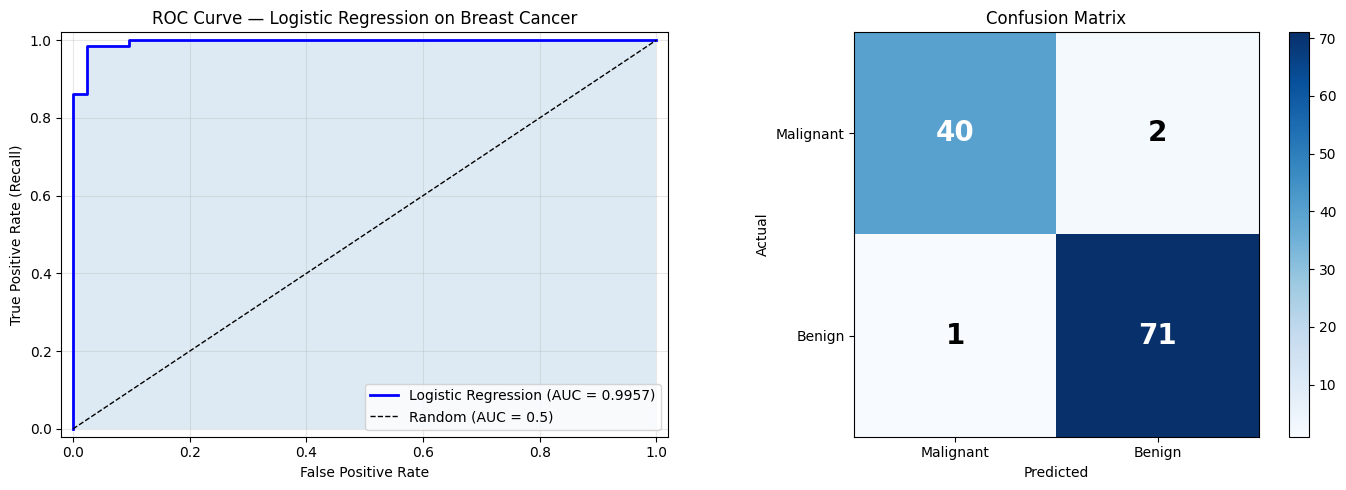

In [21]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_clf_te, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title(f'ROC Curve — Logistic Regression on Breast Cancer')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Confusion matrix heatmap
ax = axes[1]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_yticklabels(['Malignant', 'Benign'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=20, fontweight='bold')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('roc_and_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

The ROC curve **hugs the top-left corner**, with AUC $= 0.9957$ — essentially perfect class separation. To interpret: if you randomly pick one benign sample and one malignant sample, the model's predicted probability for the benign one will be higher than for the malignant one $99.57\%$ of the time.

**Translating AUC to business value:**

- AUC $= 0.50$: useless — same as a coin flip
- AUC $= 0.70$: moderately useful — suitable for many marketing or business applications
- AUC $= 0.80$: strong — useful for high-stakes decisions
- AUC $= 0.90$: excellent — production-ready for most applications
- AUC $= 0.99+$: near-perfect — typical of well-separated problems like medical imaging or biology

**Strategic insight: AUC vs accuracy.** AUC is threshold-independent — it summarizes how well the model **ranks** examples by predicted probability. Accuracy depends on the chosen threshold ($0.5$ by default). For applications where you need to **calibrate** the threshold to a specific operating point (e.g., "catch $95\%$ of fraud at any precision"), AUC is the right summary metric. For applications where a single threshold is fine, accuracy is more directly interpretable.

## 14. Model Selection

So far we have measured model quality by predictive accuracy. **In practice, model selection involves many other factors.** A logistic regression that's 1 point less accurate than a deep neural network may still be the right choice if it trains in seconds, is interpretable to regulators, and runs in microseconds at inference time.

![Figure 4-10: Model selection criteria](figures/figure_4_10.png)

**Figure 4-10.** *Model selection across multiple criteria.* The chapter's models compared along eight dimensions: simplicity, training time, ability to handle nonlinearity, robustness to overfitting, dataset-size requirements, dimensionality handling, interpretability, and need for feature scaling. No single model dominates on all axes — the right choice depends on which criteria matter most for your problem.

### Key Factors for Model Selection

The criteria that drive model choice in practice:

| Factor | What it means | High value when... |
|---|---|---|
| **Simplicity** | Fewer parameters, fewer concepts | Stakeholders are non-technical |
| **Training time** | Compute hours / minutes to train | You retrain frequently |
| **Nonlinearity handling** | Can model curved decision boundaries | Features have interactions |
| **Overfit robustness** | Generalizes from limited data | Training set is small |
| **Dataset scaling** | Performance on large $n$ | Data lake / streaming context |
| **Dimensionality** | Performance on large $p$ | Text, genomics, sensor fusion |
| **Interpretability** | Can explain individual predictions | Regulated / high-stakes applications |
| **Feature scaling needed** | Requires preprocessing | Mixed-unit raw features |

### Rule-of-Thumb Comparison Across Models

Based on the runs in this chapter and the standard literature consensus, here is a defensible quick-reference table:

| Model | Simplicity | Training Speed | Nonlinearity | Overfit Robust | Large $n$ | Large $p$ | Interpretability | Scaling Needed |
|---|---|---|---|---|---|---|---|---|
| Linear Regression  | ★★★★★ | ★★★★★ | ✗ | ★★ | ★★ | ★★ | ★★★★★ | – |
| Logistic Regression | ★★★★★ | ★★★★★ | ✗ | ★★★ | ★★★ | ★★★ | ★★★★★ | – |
| Lasso/Ridge/ElasticNet | ★★★★ | ★★★★★ | ✗ | ★★★★ | ★★★ | ★★★★ | ★★★★ | ★ |
| KNN  | ★★★★★ | ★★★★★ (no fit) | ✓ | ★ | ★ (slow predict) | ★ | ★★★ | ★★ |
| LDA | ★★★★ | ★★★★★ | ✗ | ★★★ | ★★★ | ★★ | ★★★★ | ★ |
| SVM | ★★ | ★★ | ✓ | ★★★★ | ★ | ★★★ | ★★ | ★★ |
| Decision Tree | ★★★★ | ★★★★ | ✓ | ★ | ★★★ | ★★ | ★★★★★ | – |
| Random Forest | ★★★ | ★★★ | ✓ | ★★★★ | ★★★★ | ★★★ | ★★★ | – |
| Extra Trees | ★★★ | ★★★ | ✓ | ★★★★ | ★★★★ | ★★★ | ★★ | – |
| AdaBoost | ★★★ | ★★ | ✓ | ★★ | ★★ | ★★ | ★★ | – |
| Gradient Boosting | ★★ | ★ | ✓ | ★★ | ★★★ | ★★★ | ★★ | – |
| ANN (MLP) | ★ | ★ | ✓ | ★★ | ★★★★★ | ★★★★ | ★ | ★★ |

### Model Trade-Off

Often there is no single best model — only a **best model for this set of constraints**. Some classic dilemmas:

- **Accuracy vs interpretability.** Gradient boosting and deep neural networks can be more accurate than logistic regression, but their predictions are harder to explain. In credit decisions or hiring, the regulatory cost of an unexplainable rejection often makes the simpler model the *practical* winner.

- **Training time vs accuracy.** A neural network might give $0.5$ percentage points better accuracy at the cost of $100\times$ longer training. If you retrain daily, that cost is amortized; if you retrain hourly, it isn't.

- **Latency vs flexibility.** KNN is trivial to train and trivial to update, but classifying a single new point requires scanning all training data. For real-time inference at scale, you need a model that has compressed the training data into compact parameters — almost any model except KNN.

**A pragmatic workflow for model selection:**

1. **Establish a baseline.** Logistic regression or linear regression — fast, interpretable, sets the floor.
2. **Try 3-4 fundamentally different model classes** with default hyperparameters. Use CV on the training set.
3. **For the top 1-2, do serious hyperparameter tuning.** Grid search, random search, or Bayesian optimization.
4. **Check the practical constraints.** Training time, inference latency, interpretability, deployment compatibility.
5. **Pick the model where the marginal accuracy gain over the simpler one is worth the marginal cost.**

The case studies in Chapters 5 and 6 walk through this workflow on real financial datasets.

## 15. Chapter Summary

We surveyed the full landscape of classical supervised learning:

**Linear models** — Linear Regression, Logistic Regression, Lasso, Ridge, Elastic Net — are the foundation. Fast, interpretable, well-understood, and surprisingly hard to beat on well-conditioned tabular data. The breast-cancer experiments throughout the chapter confirm this: logistic regression with light regularization matched or beat every more complex model.

**Distance- and kernel-based models** — KNN, SVM — exploit local structure (KNN) or implicit projections (SVM kernels). KNN's training-free nature makes it a strong baseline; SVM with the right kernel and $C$ is competitive across many tasks but harder to tune.

**LDA** is the generative cousin of logistic regression. Cheap, fast, doubles as dimensionality reduction.

**Trees and ensembles** — CART, Random Forest, Extra Trees, AdaBoost, Gradient Boosting — capture nonlinearity and interactions without requiring scaling. **Gradient boosting** (and its modern descendants XGBoost / LightGBM / CatBoost) is the dominant tabular-data ensemble in production today.

**Neural networks** become the right choice at scale — large datasets, high-dimensional structured inputs, complex multi-task setups. On small tabular problems, they are usually overkill.

**Model performance** is governed by the bias-variance trade-off. **Cross-validation** estimates generalization performance from the training set alone. **Grid search** + CV is the standard hyperparameter tuning protocol.

**Evaluation metrics** must match the business goal. RMSE for regression when outliers matter; MAE when they don't. Accuracy is dangerous on imbalanced data; precision-recall and AUC are more informative. The confusion matrix is the ground truth — always inspect it for binary classifiers.

**Model selection** is a multi-criteria decision. Accuracy is one axis; interpretability, training time, inference latency, robustness, and scalability are others. The best model is the simplest one that meets the requirements — not the most accurate one on a leaderboard.

**Final scoreboard on this chapter's two datasets:**

| Dataset | Best Test Score | Winning Model |
|---|---:|---|
| Diabetes (regression) | $R^2 = 0.4937$ | **SVR (RBF kernel)** |
| Breast cancer (classification) | Accuracy $98.25\%$ | **Logistic Regression** and **RBF SVM** (tied) |

On classification a regularized linear model tied with the kernel SVM at the top. On regression the kernel model just barely beat the linear baseline. **The recurring lesson of supervised learning**: complexity is a tool, not an end. Start with the simplest model, beat it only when you have evidence the data demands more, and quantify the cost-vs-benefit of every step up in complexity.

---

### References and Further Reading

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. — The definitive treatment of every model in this chapter, with full mathematical derivations.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer. — Accessible companion to ESL with R/Python labs.
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly. — The book the chapter recommends for thorough coverage.
- Tatsat, H., Puri, S., & Lookabaugh, B. (2020). *Machine Learning and Data Science Blueprints for Finance*. O'Reilly. — This notebook accompanies Chapter 4.
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32. — The Random Forest paper.
- Freund, Y., & Schapire, R. E. (1997). *A decision-theoretic generalization of on-line learning and an application to boosting*. JCSS, 55(1), 119-139. — AdaBoost.
- Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine*. Annals of Statistics, 29(5), 1189-1232. — Gradient Boosting.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. KDD '16. — Modern boosting at scale.